# Statistics for model adaption part

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import result_handler
import re
from sklearn.metrics import jaccard_score, roc_auc_score

#setting filepaths of the results

pi_results_filepath = "../prediction_results/PI_results/PI_"

nnrti_results_filepath = "../prediction_results/NNRTI_results/NNRTI_"

nrti_results_filepath = "../prediction_results/NRTI_results/NRTI_"

ini_results_filepath = "../prediction_results/INI_results/INI_"



#creating lists with filepaths for later visualisation
filepath_list = [ini_results_filepath, nnrti_results_filepath, nrti_results_filepath, pi_results_filepath]




#setting filepaths for the benchmarking datasets

pi_results_filepath_ml = "../prediction_results/PI_results/benchmarkings/PI_"

nnrti_results_filepath_ml = "../prediction_results/NNRTI_results/benchmarkings/NNRTI_"

nrti_results_filepath_ml = "../prediction_results/NRTI_results/benchmarkings/NRTI_"

ini_results_filepath_ml = "../prediction_results/INI_results/benchmarkings/INI_"



#creating lists with filepaths for later visualisation
filepath_list_ml = [ini_results_filepath_ml, nnrti_results_filepath_ml, nrti_results_filepath_ml, pi_results_filepath_ml]


## MuLa-TabICL struggles with HIVDRD compared to PT methods

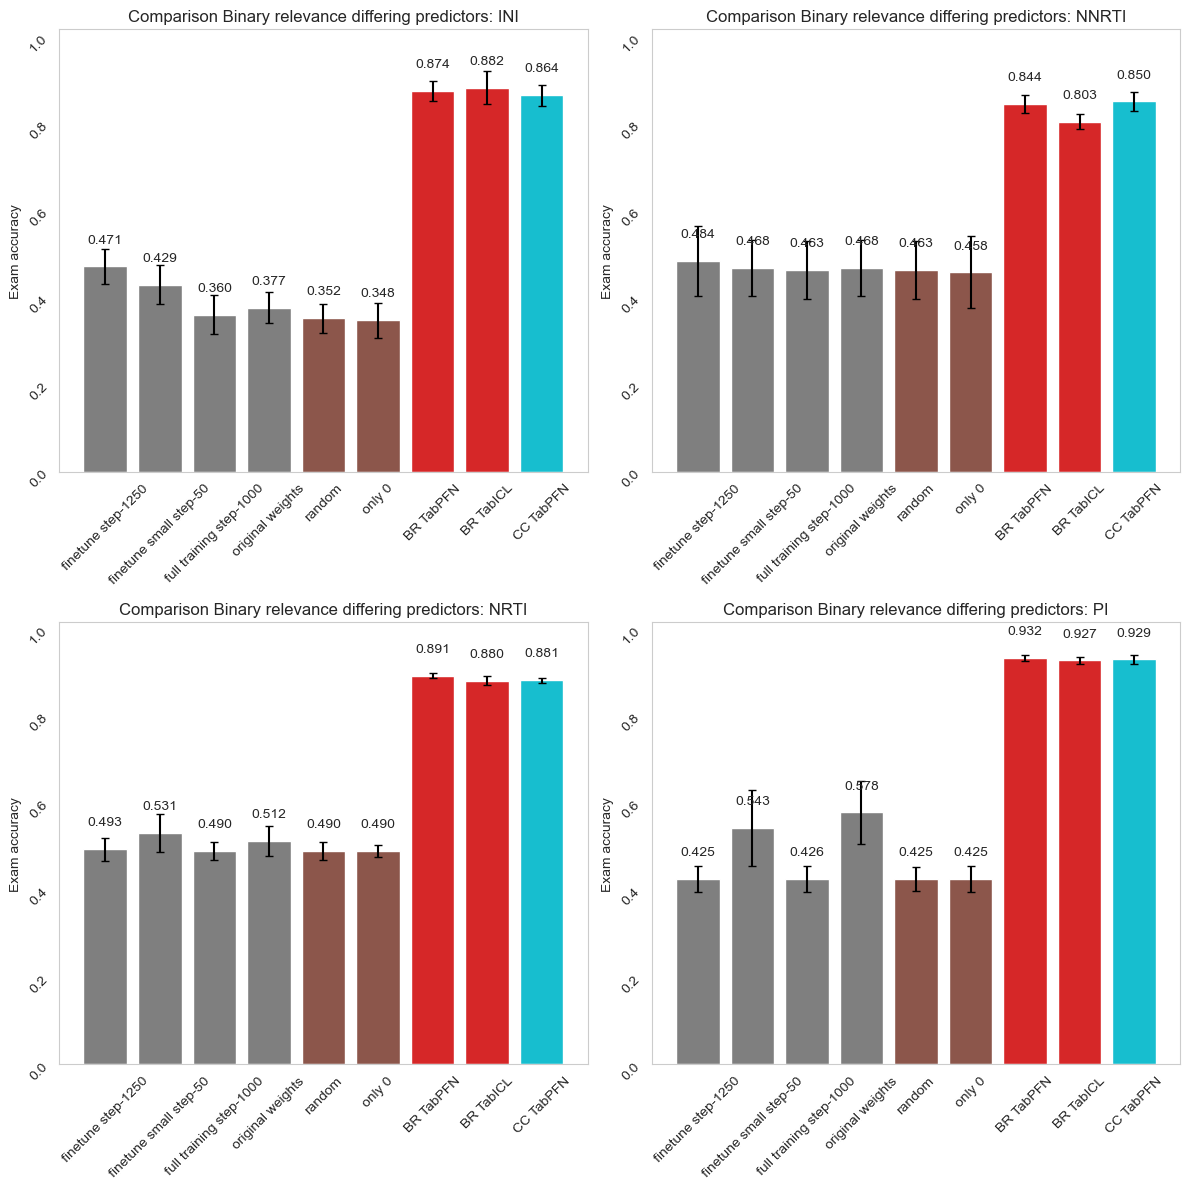

In [4]:
modeltype = "MuLaTabICL_"

models = [
    "finetune_step-1250",
    "finetune_stage3_step-50",
    "full_model_step-1000",
    "abicl-classifier-v1.1-0506",
    "random_test/step-1"]

ending = "_5_fold_new_loss_sigmoid.csv"


ml_models = [modeltype + x for x in models]



sub_accs_fold_mean, sub_accs_fold_std = result_handler.calc_metrics(filepath_list, ml_models, result_handler.exam_acc, {"nan_mode": "warning"}, ending=ending, drop_na=False)


for path in filepath_list:


    results = pd.read_csv(path + "Binary_Relevance_5_fold_homebrew_prediction_new_save.csv")

    results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

    subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: result_handler.exam_acc(pd.DataFrame(np.ones_like(x.filter(regex="Pred_*"))), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)

    sub_accs_fold_mean[path.split("/")[-1].strip("_")].append(subs_accs_groups.mean())
    sub_accs_fold_std[path.split("/")[-1].strip("_")].append(subs_accs_groups.std())



files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_5_fold_tabicl_homebrew_prediction_new_save_woNaN.csv", "Classifier_Chain_5_fold_homebrew_prediction_woNaN_new_save.csv"]

tmp_sub_accs_fold_mean, tmp_sub_accs_fold_std = result_handler.calc_metrics(filepath_list, files, result_handler.exam_acc,metric_args={}, drop_na=True)

[sub_accs_fold_mean[x].extend(tmp_sub_accs_fold_mean[x]) for x in sub_accs_fold_mean.keys()]
[sub_accs_fold_std[x].extend(tmp_sub_accs_fold_std[x]) for x in sub_accs_fold_std.keys()]




df_sub_accs_groups_mean = pd.DataFrame(sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(sub_accs_fold_std)


models_w_TabPFN = ["only 0", "BR TabPFN", "BR TabICL", "CC TabPFN"]

color = ["tab:gray"] * 4 + ["tab:brown"] * 2 + ["tab:red"] * 2 + ["tab:cyan"]

fig, axs = plt.subplots(2, 2, figsize=(12, 12))
#fig.tight_layout()

x_ticks = ["finetune step-1250",
    "finetune small step-50",
    "full training step-1000",
    "original weights",
    "random"]

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):


    labels = x_ticks  + models_w_TabPFN
    p = axs[i].bar(labels, df_sub_accs_groups_mean[drug], color=color)
    axs[i].errorbar(labels, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")


    axs[i].bar_label(p, label_type="edge", padding=15, fmt="%.3f")

    axs[i].grid(False)

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(x_ticks)
    axs[i].tick_params(rotation=45)
    axs[i].set_ylabel('Exam accuracy')
    axs[i].set_ylim(0, 1.0  * 1.015)
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)

fig.tight_layout()
#plt.show()

#plt.savefig("../figures/07_ma_not_as_good/ma_comp_exam_acc.png")


============INI============
finetune_step-1250
finetune_stage3_step-50
bal_prior_step-1000
finetune_step-2000
bal_prior_step-1350
finetune_step-3150
full_model_step-1000
abicl-classifier-v1.1-0506
random_test/step-1
============NNRTI============
finetune_step-1250
finetune_stage3_step-50
bal_prior_step-1000
finetune_step-2000
bal_prior_step-1350
finetune_step-3150
full_model_step-1000
abicl-classifier-v1.1-0506
random_test/step-1
============NRTI============
finetune_step-1250
finetune_stage3_step-50
bal_prior_step-1000
finetune_step-2000
bal_prior_step-1350
finetune_step-3150
full_model_step-1000
abicl-classifier-v1.1-0506
random_test/step-1
============PI============
finetune_step-1250
finetune_stage3_step-50
bal_prior_step-1000
finetune_step-2000
bal_prior_step-1350
finetune_step-3150
full_model_step-1000
abicl-classifier-v1.1-0506
random_test/step-1


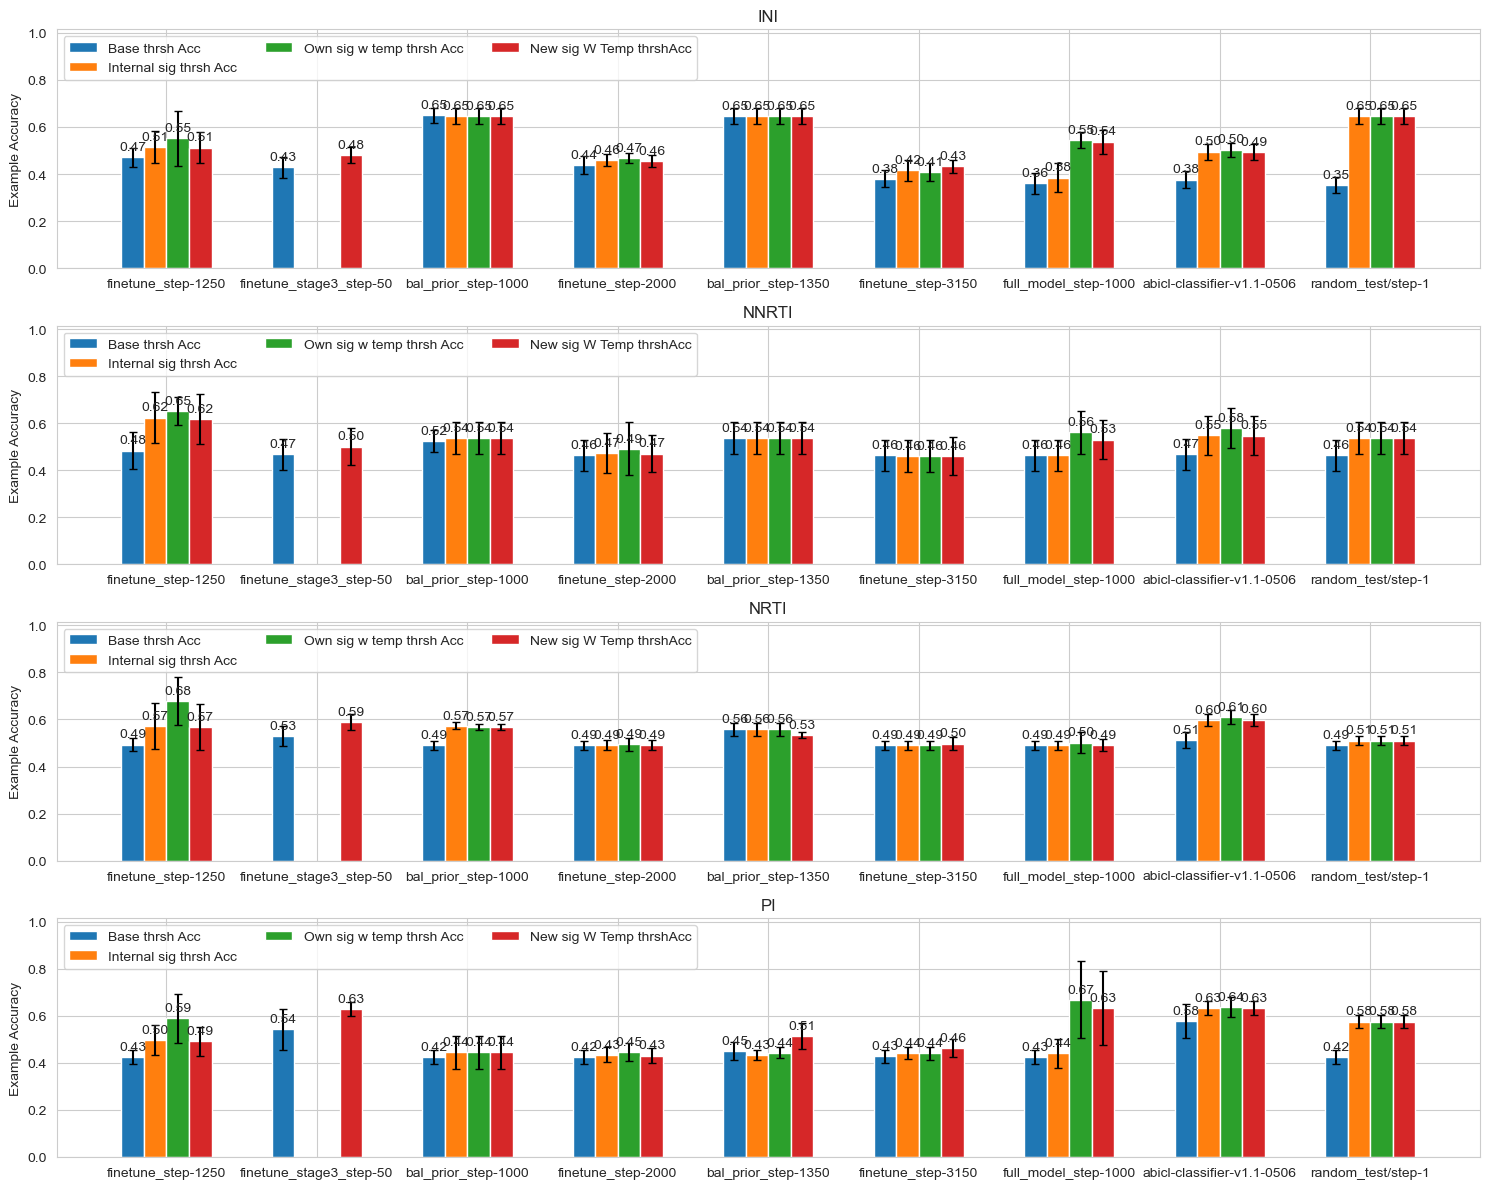

In [15]:
modeltype = "MuLaTabICL_"

models = [
    "finetune_step-1250",
    "finetune_stage3_step-50",
    "bal_prior_step-1000",
    "finetune_step-2000",
    "bal_prior_step-1350",
    "finetune_step-3150",
    "full_model_step-1000",
    "abicl-classifier-v1.1-0506",
    "random_test/step-1"]

ending = "_5_fold_new_loss_sigmoid.csv"

thrshlds_internal = {"finetune_step-1250":  0.6860411,
"bal_prior_step-1000":  0.5292327,
"finetune_step-2000":  0.747135,
"bal_prior_step-1350":  0.504576,
"finetune_step-3150":  0.67952967,
"full_model_step-1000":  0.581367369,
"abicl-classifier-v1.1-0506":  0.709058,
"random_test/step-1":  np.nan,}

thrshlds_temp_sig = {"finetune_step-1250":  0.7540253,
"bal_prior_step-1000":  0.52958435,
"finetune_step-2000":  0.79760474,
"bal_prior_step-1350":  0.5100705,
"finetune_step-3150":  0.67292804,
"full_model_step-1000":  0.748620175,
"abicl-classifier-v1.1-0506":  0.7361159,
"random_test/step-1":  np.nan,}

thrshlds_temp_sig_new = {"finetune_step-1250":  0.6830695,
"finetune_stage3_step-50":  0.62230235,
"bal_prior_step-1000":  0.53245866,
"finetune_step-2000":  0.721869,
"bal_prior_step-1350":  0.5226037,
"finetune_step-3150":  0.82249993,
"full_model_step-1000":  0.73285752,
"abicl-classifier-v1.1-0506":  0.7113368,
"random_test/step-1":  np.nan,}

results_mean = []

results_std = []

for path in filepath_list:

    old_acc_mean = []
    exac_int_mean = []
    exac_tmp_mean = []
    exac_new_mean = []

    old_acc_std = []
    exac_int_std = []
    exac_tmp_std = []
    exac_new_std = []

    print("============" + path.split("/")[-1].strip("_") + "============")

    for model in models:

        print(model)

        pred = pd.read_csv(path + modeltype + model + ending)
        pred_proba = pd.read_csv(path + modeltype + model + "_probabilities" + ending)

        kfolds = pred_proba["kFolds"]
        true_labels = pred.filter(regex="True_*")
        pred_labels_old = pred.filter(regex="Pred_*")
        pred_proba = pred_proba.filter(regex="Pred_*")
        #print(max(pred_proba.max()), min(pred_proba.min()))

        true_label_arr = np.array(true_labels)
        pred_proba_arr = np.array(pred_proba)

        old_acc_groups = pred.groupby(by="kFolds").apply(
        lambda x: result_handler.exam_acc(x.filter(regex="True_*"), x.filter(regex="Pred_*")),
        include_groups=False)

        old_acc_mean.append(old_acc_groups.mean())
        old_acc_std.append(old_acc_groups.std())

        if model in list(thrshlds_internal.keys()):
            pred_labels_new = (pred_proba > thrshlds_internal[model]) * 1.0

            df = pd.concat([true_labels, pred_labels_new, kfolds], axis=1)

            exac_int_groups = df.groupby(by="kFolds").apply(
                lambda x: result_handler.exam_acc(x.filter(regex="True_*"), x.filter(regex="Pred_*")),
                include_groups=False)

            exac_int_mean.append(exac_int_groups.mean())
            exac_int_std.append(exac_int_groups.std())
        else:
            exac_int_mean.append(np.nan)
            exac_int_std.append(np.nan)

        if model in list(thrshlds_temp_sig.keys()):
            pred_labels_new = (pred_proba > thrshlds_temp_sig[model]) * 1.0

            df = pd.concat([true_labels, pred_labels_new, kfolds], axis=1)

            exac_tmp_groups = df.groupby(by="kFolds").apply(
                lambda x: result_handler.exam_acc(x.filter(regex="True_*"), x.filter(regex="Pred_*")),
                include_groups=False)

            exac_tmp_mean.append(exac_tmp_groups.mean())
            exac_tmp_std.append(exac_tmp_groups.std())
        else:
            exac_tmp_mean.append(np.nan)
            exac_tmp_std.append(np.nan)

        pred_labels_new = (pred_proba > thrshlds_temp_sig_new[model]) * 1.0

        df = pd.concat([true_labels, pred_labels_new, kfolds], axis=1)

        exac_tmp_groups = df.groupby(by="kFolds").apply(
            lambda x: result_handler.exam_acc(x.filter(regex="True_*"), x.filter(regex="Pred_*")),
            include_groups=False)

        exac_new_mean.append(exac_tmp_groups.mean())
        exac_new_std.append(exac_tmp_groups.std())



    model_results_mean= {"Base thrsh Acc": old_acc_mean,
                                 "Internal sig thrsh Acc":exac_int_mean,
                         "Own sig w temp thrsh Acc":exac_tmp_mean,
                                 "New sig W Temp thrshAcc":exac_new_mean}

    model_results_std= {"Base thrsh Acc": old_acc_std,
                                 "Internal sig thrsh Acc":exac_int_std,
                        "Own sig w temp thrsh Acc":exac_tmp_std,
                                 "New sig W Temp thrshAcc":exac_new_std}

    results_mean.append(model_results_mean)
    results_std.append(model_results_std)


x = np.arange(len(models))  # the label locations
width = 0.15  # the width of the bars

fig, axs = plt.subplots(4, figsize=(15, 12),layout='tight')

for i, path in enumerate(filepath_list):

    multiplier = -0.5

    ax = axs[i]

    for attribute, measurement in results_mean[i].items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, fmt='%.2f', padding=3)
        ax.errorbar(x + offset, measurement, yerr=results_std[i][attribute],capsize=3, fmt="none", ecolor="black")
        multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Example Accuracy')
    ax.set_title(path.split("/")[-1].strip("_"))
    ax.set_xticks(x + width, models)
    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, 1.015)

plt.show()

============INI============
finetune_step-1250
finetune_stage3_step-50
full_model_step-1000
abicl-classifier-v1.1-0506
random_test/step-1
../prediction_results/INI_results/INI_Binary_Relevance_probabilities_5_fold_MOC_prediction_new_save.csv
../prediction_results/INI_results/INI_Binary_Relevance_probabilities_5_fold_tabicl_homebrew_prediction_new_save_woNaN.csv
../prediction_results/INI_results/INI_Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv
============NNRTI============
finetune_step-1250
finetune_stage3_step-50
full_model_step-1000
abicl-classifier-v1.1-0506
random_test/step-1
../prediction_results/NNRTI_results/NNRTI_Binary_Relevance_probabilities_5_fold_MOC_prediction_new_save.csv
../prediction_results/NNRTI_results/NNRTI_Binary_Relevance_probabilities_5_fold_tabicl_homebrew_prediction_new_save_woNaN.csv
../prediction_results/NNRTI_results/NNRTI_Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv
============NRTI============

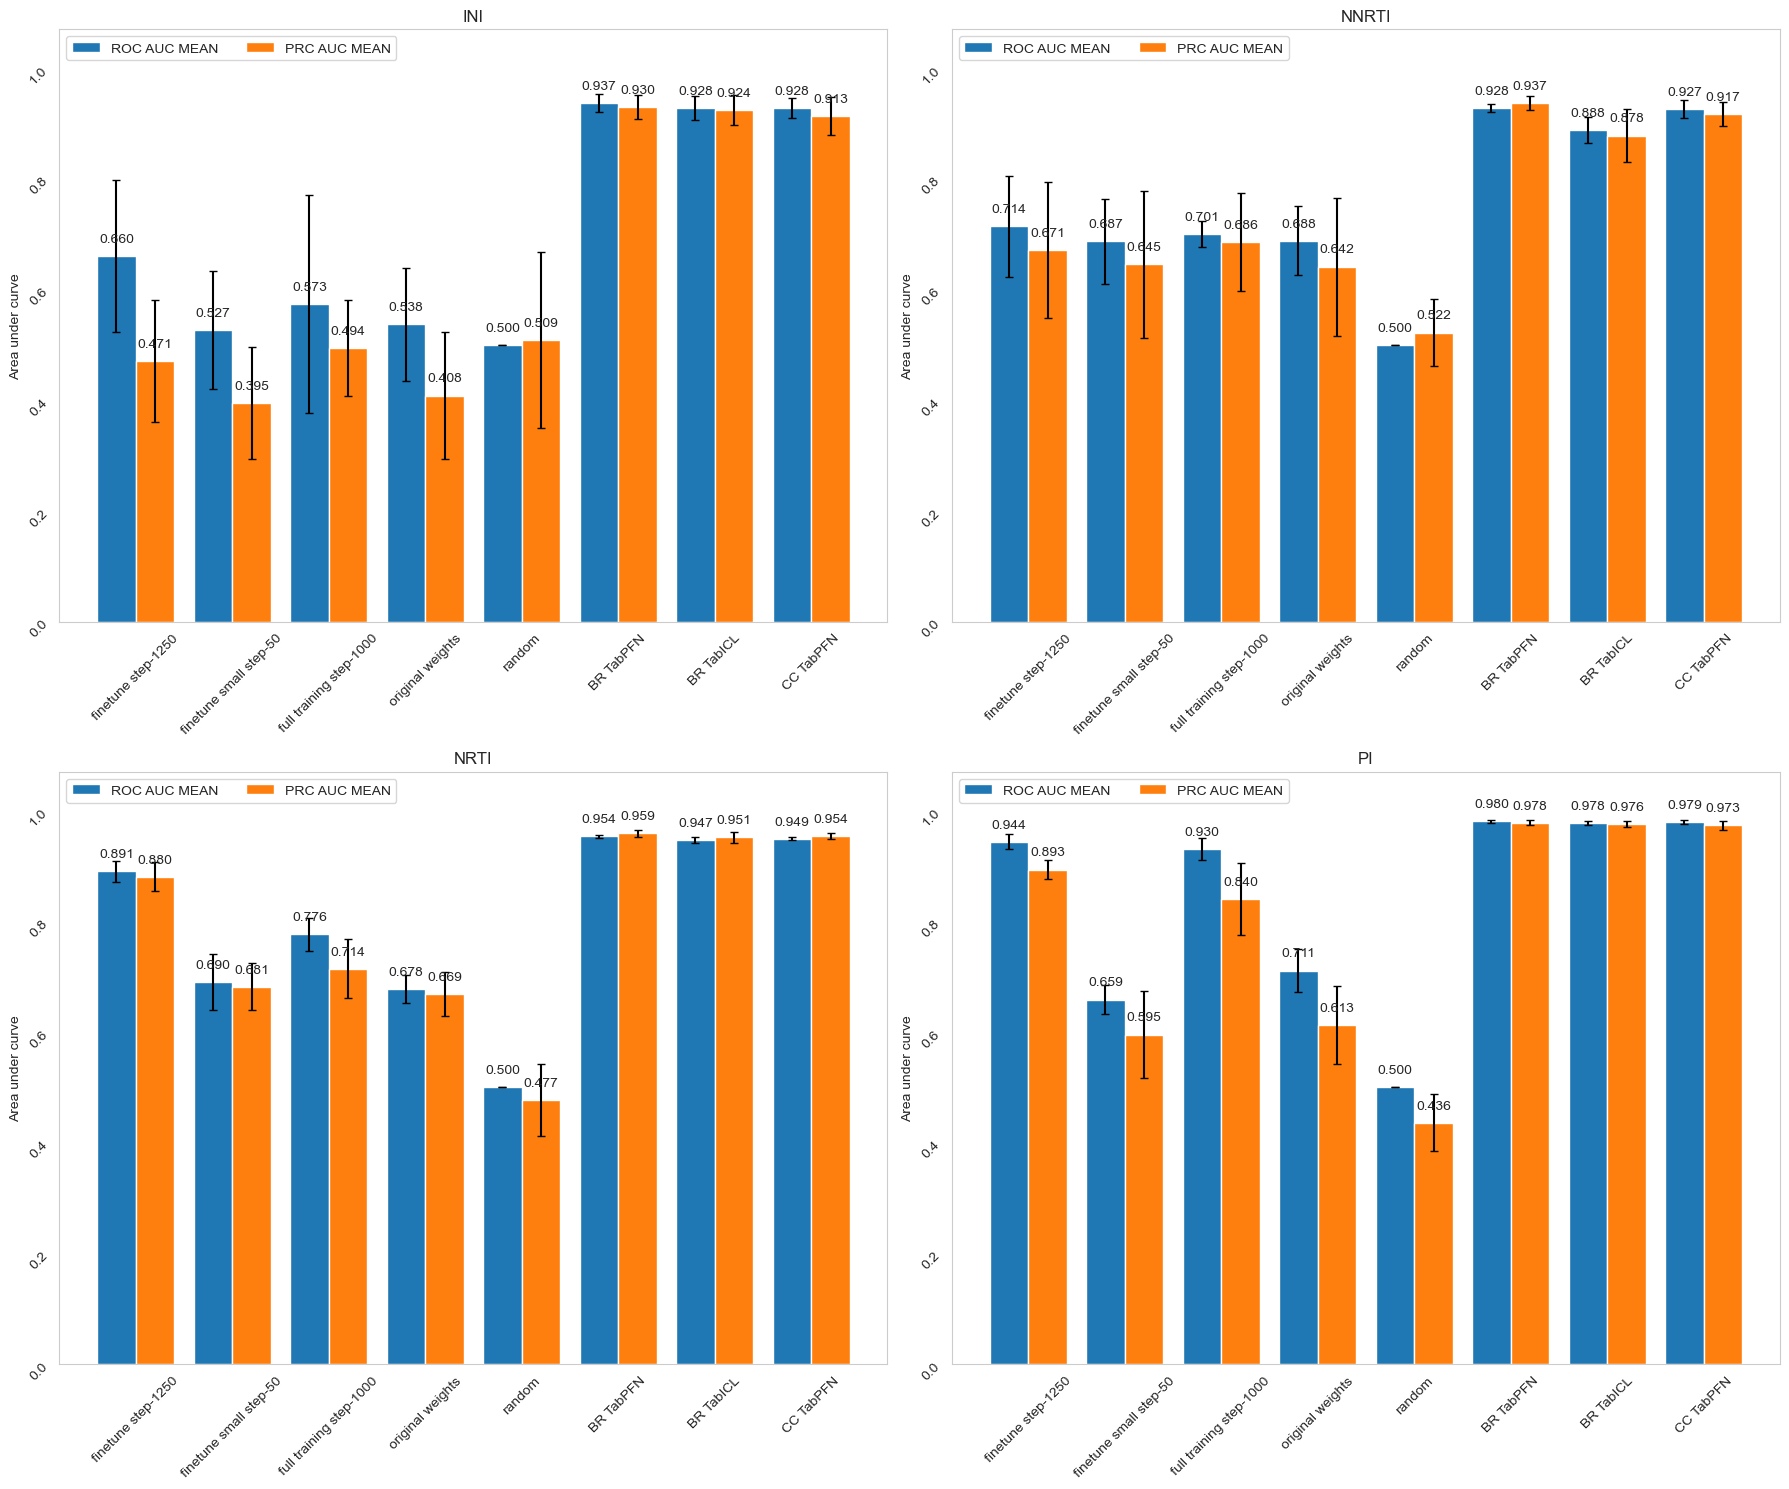

In [15]:



modeltype = "MuLaTabICL_"

models = [
    "finetune_step-1250",
    "finetune_stage3_step-50",
    "full_model_step-1000",
    "abicl-classifier-v1.1-0506",
    "random_test/step-1"]


results_mean = []
results_std = []

ending = "_5_fold_new_loss_sigmoid.csv"

#path="../prediction_results/scene.csv_results/scene.csv_"

for path in filepath_list:

    roc_auc_mean = []
    roc_auc_std = []
    prc_auc_mean = []
    prc_auc_std = []



    print("============" + path.split("/")[-1].strip("_") + "============")

    for model in models:

        print(model)

        pred_proba = pd.read_csv(path + modeltype + model.strip(".ckpt") + "_probabilities" + ending)



        roc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: roc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*"))), include_groups=False)
        prc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: result_handler.prc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*")), multiclass="ovr"), include_groups=False)


        roc_auc_mean.append(roc_auc.mean())
        roc_auc_std.append(roc_auc.std())

        prc_auc_mean.append(prc_auc.mean())
        prc_auc_std.append(prc_auc.std())

        #roc_auc.append(roc_auc_score(true_label_arr, pred_proba_arr))
        #prc_auc.append(result_handler.prc_auc_score(true_label_arr, pred_proba_arr, multiclass="ovr"))


    benchmark_prefix = re.sub('[^/]+_$', '', path) + "benchmarkings/" + path.split("/")[-1]

    #comp_mod = [benchmark_prefix + "BR_XGB_probabilities.csv", benchmark_prefix + "CC_XGB_probabilities.csv", path + "Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv", path + "Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv"]

    comp_mod = [path + "Binary_Relevance_probabilities_5_fold_MOC_prediction_new_save.csv", path + "Binary_Relevance_probabilities_5_fold_tabicl_homebrew_prediction_new_save_woNaN.csv",path + "Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv"]

    for model in comp_mod:

        print(model)


        pred_proba = pd.read_csv(model)

        pred_proba.dropna(subset=pred_proba.columns[pred_proba.columns.str.startswith('True_')].tolist(), inplace=True)


        roc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: roc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*"))), include_groups=False)
        prc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: result_handler.prc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*")), multiclass="ovr"), include_groups=False)


        roc_auc_mean.append(roc_auc.mean())
        roc_auc_std.append(roc_auc.std())

        prc_auc_mean.append(prc_auc.mean())
        prc_auc_std.append(prc_auc.std())

    '''
    model_results= {"ROC AUC MEAN":roc_auc_mean,
                    "ROC AUC STD":roc_auc_std,
                    "PRC AUC MEAN":prc_auc_mean,
                    "PRC AUC STD":prc_auc_std}
    '''

    results_mean.append({"ROC AUC MEAN":roc_auc_mean,
                    "PRC AUC MEAN":prc_auc_mean})

    results_std.append({"ROC AUC STD":roc_auc_std,
                    "PRC AUC STD":prc_auc_std})


x_ticks = ["finetune step-1250",
    "finetune small step-50",
    "full training step-1000",
    "original weights",
    "random"]  + ["BR TabPFN", "BR TabICL", "CC TabPFN"]

x = np.arange(len(x_ticks))  # the label locations
width = 0.4  # the width of the bars

fig, axs = plt.subplots(2, 2, figsize=(18, 15),layout='tight')

axs = axs.flatten()

for i, path in enumerate(filepath_list):

    multiplier = 0.5

    ax = axs[i]

    for attribute, measurement in results_mean[i].items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        print(results_std[i][attribute.strip("MEAN") + "STD"])
        ax.errorbar(x + offset, measurement, yerr=results_std[i][attribute.strip("MEAN") + "STD"],capsize=3, fmt="none", ecolor="black")
        ax.bar_label(rects, fmt='%.3f', padding=8)
        multiplier += 1

    ax.grid(False)
    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Area under curve')
    ax.set_title(path.split("/")[-1].strip("_"))
    ax.tick_params(rotation=45)
    ax.set_xticks(x + width, x_ticks)
    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, 1.07)

#plt.show()

plt.savefig("../figures/07_ma_not_as_good/ma_comp_auc.png")

## Different approaches for improving TabICL do not yield better results

============INI============
finetune_step-1250.ckpt
finetune_stage3_step-50
bal_prior_step-1000.ckpt
full_model_step-1000.ckpt
label_enc_step-1000.ckpt
cat_feat_step-1000.ckpt
zlpr_loss_step-700.ckpt
omb_step-1000.ckpt
../prediction_results/INI_results/INI_Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv
============NNRTI============
finetune_step-1250.ckpt
finetune_stage3_step-50
bal_prior_step-1000.ckpt
full_model_step-1000.ckpt
label_enc_step-1000.ckpt
cat_feat_step-1000.ckpt
zlpr_loss_step-700.ckpt
omb_step-1000.ckpt
../prediction_results/NNRTI_results/NNRTI_Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv
============NRTI============
finetune_step-1250.ckpt
finetune_stage3_step-50
bal_prior_step-1000.ckpt
full_model_step-1000.ckpt
label_enc_step-1000.ckpt
cat_feat_step-1000.ckpt
zlpr_loss_step-700.ckpt
omb_step-1000.ckpt
../prediction_results/NRTI_results/NRTI_Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv
=======

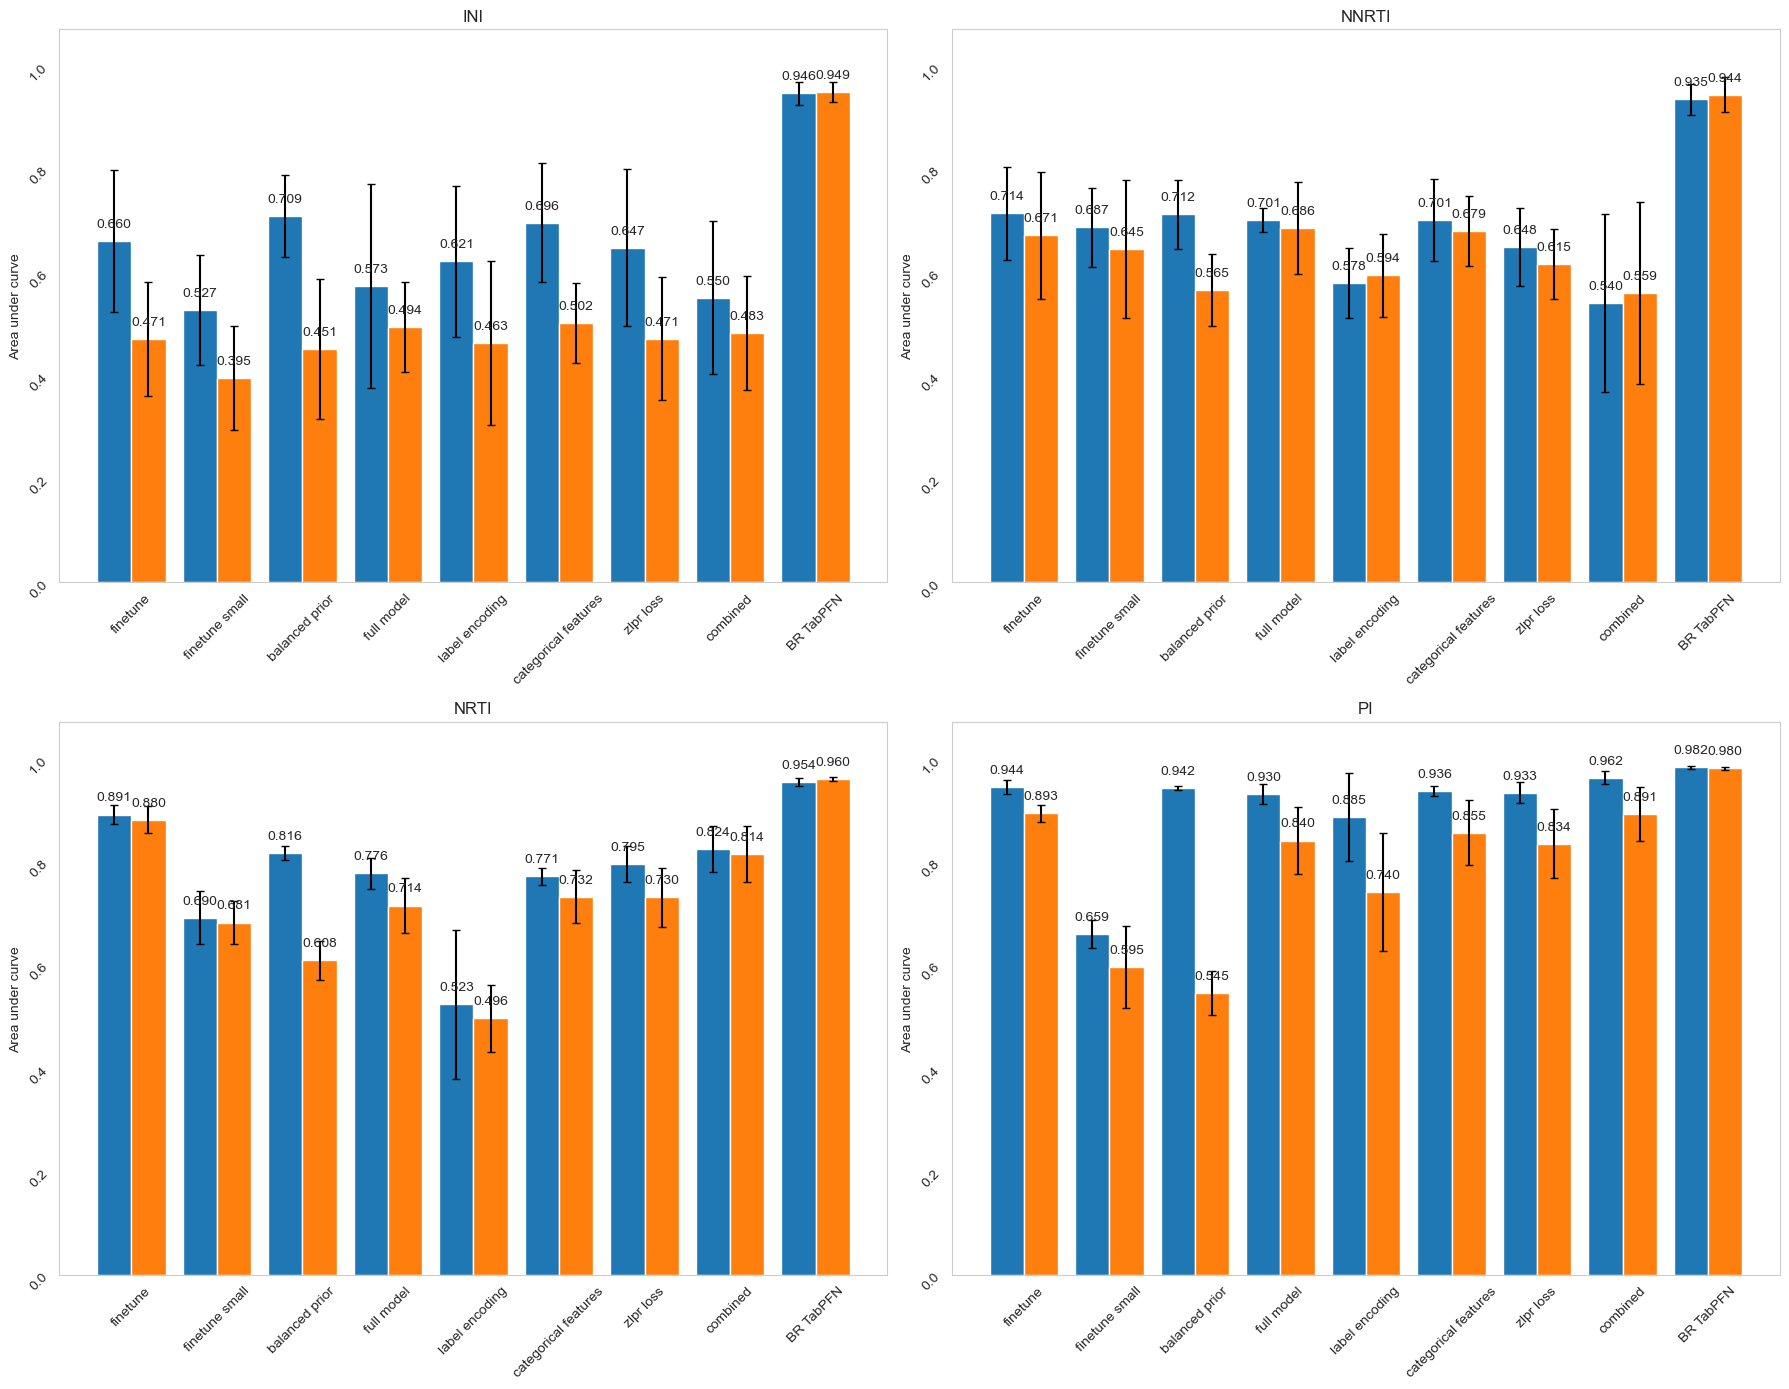

In [66]:



modeltype = "MuLaTabICL_"

models = [
    "finetune_step-1250.ckpt",
    "finetune_stage3_step-50",
    "bal_prior_step-1000.ckpt",
    "full_model_step-1000.ckpt",
    "label_enc_step-1000.ckpt",
    "cat_feat_step-1000.ckpt",
    "zlpr_loss_step-700.ckpt",
    "omb_step-1000.ckpt"]



results_mean = []
results_std = []

ending = "_5_fold_new_loss_sigmoid.csv"

#path="../prediction_results/scene.csv_results/scene.csv_"

for path in filepath_list:

    roc_auc_mean = []
    roc_auc_std = []
    prc_auc_mean = []
    prc_auc_std = []



    print("============" + path.split("/")[-1].strip("_") + "============")

    for model in models:

        print(model)

        pred_proba = pd.read_csv(path + modeltype + model.strip(".ckpt") + "_probabilities" + ending)



        roc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: roc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*"))), include_groups=False)
        prc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: result_handler.prc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*")), multiclass="ovr"), include_groups=False)


        roc_auc_mean.append(roc_auc.mean())
        roc_auc_std.append(roc_auc.std())

        prc_auc_mean.append(prc_auc.mean())
        prc_auc_std.append(prc_auc.std())

        #roc_auc.append(roc_auc_score(true_label_arr, pred_proba_arr))
        #prc_auc.append(result_handler.prc_auc_score(true_label_arr, pred_proba_arr, multiclass="ovr"))


    benchmark_prefix = re.sub('[^/]+_$', '', path) + "benchmarkings/" + path.split("/")[-1]

    #comp_mod = [benchmark_prefix + "BR_XGB_probabilities.csv", benchmark_prefix + "CC_XGB_probabilities.csv", path + "Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv", path + "Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv"]

    comp_mod = [path + "Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv"]

    for model in comp_mod:

        print(model)


        pred_proba = pd.read_csv(model)

        pred_proba.dropna(subset=pred_proba.columns[pred_proba.columns.str.startswith('True_')].tolist(), inplace=True)


        roc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: roc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*"))), include_groups=False)
        prc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: result_handler.prc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*")), multiclass="ovr"), include_groups=False)


        roc_auc_mean.append(roc_auc.mean())
        roc_auc_std.append(roc_auc.std())

        prc_auc_mean.append(prc_auc.mean())
        prc_auc_std.append(prc_auc.std())

    '''
    model_results= {"ROC AUC MEAN":roc_auc_mean,
                    "ROC AUC STD":roc_auc_std,
                    "PRC AUC MEAN":prc_auc_mean,
                    "PRC AUC STD":prc_auc_std}
    '''

    results_mean.append({"ROC AUC MEAN":roc_auc_mean,
                    "PRC AUC MEAN":prc_auc_mean})

    results_std.append({"ROC AUC STD":roc_auc_std,
                    "PRC AUC STD":prc_auc_std})

x_ticks = [
    "finetune",
    "finetune small",
    "balanced prior",
    "full model",
    "label encoding",
    "categorical features",
    "zlpr loss",
    "combined"] + ["BR TabPFN"]

x = np.arange(len(x_ticks))  # the label locations
width = 0.4  # the width of the bars

fig, axs = plt.subplots(2, 2, figsize=(18, 14),layout='tight')

axs = axs.flatten()

for i, path in enumerate(filepath_list):

    multiplier = 0.5

    ax = axs[i]

    for attribute, measurement in results_mean[i].items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        print(results_std[i][attribute.strip("MEAN") + "STD"])
        ax.errorbar(x + offset, measurement, yerr=results_std[i][attribute.strip("MEAN") + "STD"],capsize=3, fmt="none", ecolor="black")
        ax.bar_label(rects, fmt='%.3f', padding=8)
        multiplier += 1

    ax.grid(False)
    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Area under curve')
    ax.set_title(path.split("/")[-1].strip("_"))
    ax.tick_params(rotation=45)
    ax.set_xticks(x + width, x_ticks)
    #ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, 1.07)

#plt.show()

#plt.savefig("../figures/08_diff_approaches/diff_app_auc.png")

## Prolonged Training deteriorates predictive power of TabICL models

[0.13695950572182747, 0.1449181044959293, 0.15244354997585452, 0.0798424228159466, 0.06897389242266988, 0.04509326861478053, 0.1966678890441228, 0.14883291991785993, 0.14631666388504072, 0.16970759325770732, 0.12588896389942997, 0.11524036785690916, 0.08362593260826605, 0.10615799301488307, 0.15201239518357318, 0.06442653032559979, 0.14814364356439177, 0.19190515239435646]
[0.1106084071021821, 0.11230566784882505, 0.1028680140682265, 0.13622083311988084, 0.10381343650814197, 0.135183695135823, 0.08675572175914079, 0.08340813421582785, 0.15869575200471972, 0.11977980949828504, 0.10406313805695439, 0.07668658247458146, 0.09490597511234405, 0.06526005378219711, 0.11881612626322684, 0.07617869974169085, 0.11065590499154106, 0.08450799416789236]
[0.090338757220495, 0.1509324112062131, 0.1688393218190107, 0.06644086293969602, 0.06691169787379, 0.07165989785900427, 0.023452062088975042, 0.18471294586342618, 0.06786458368251946, 0.1780563590068879, 0.16186439489618917, 0.07898620383642271, 0.1

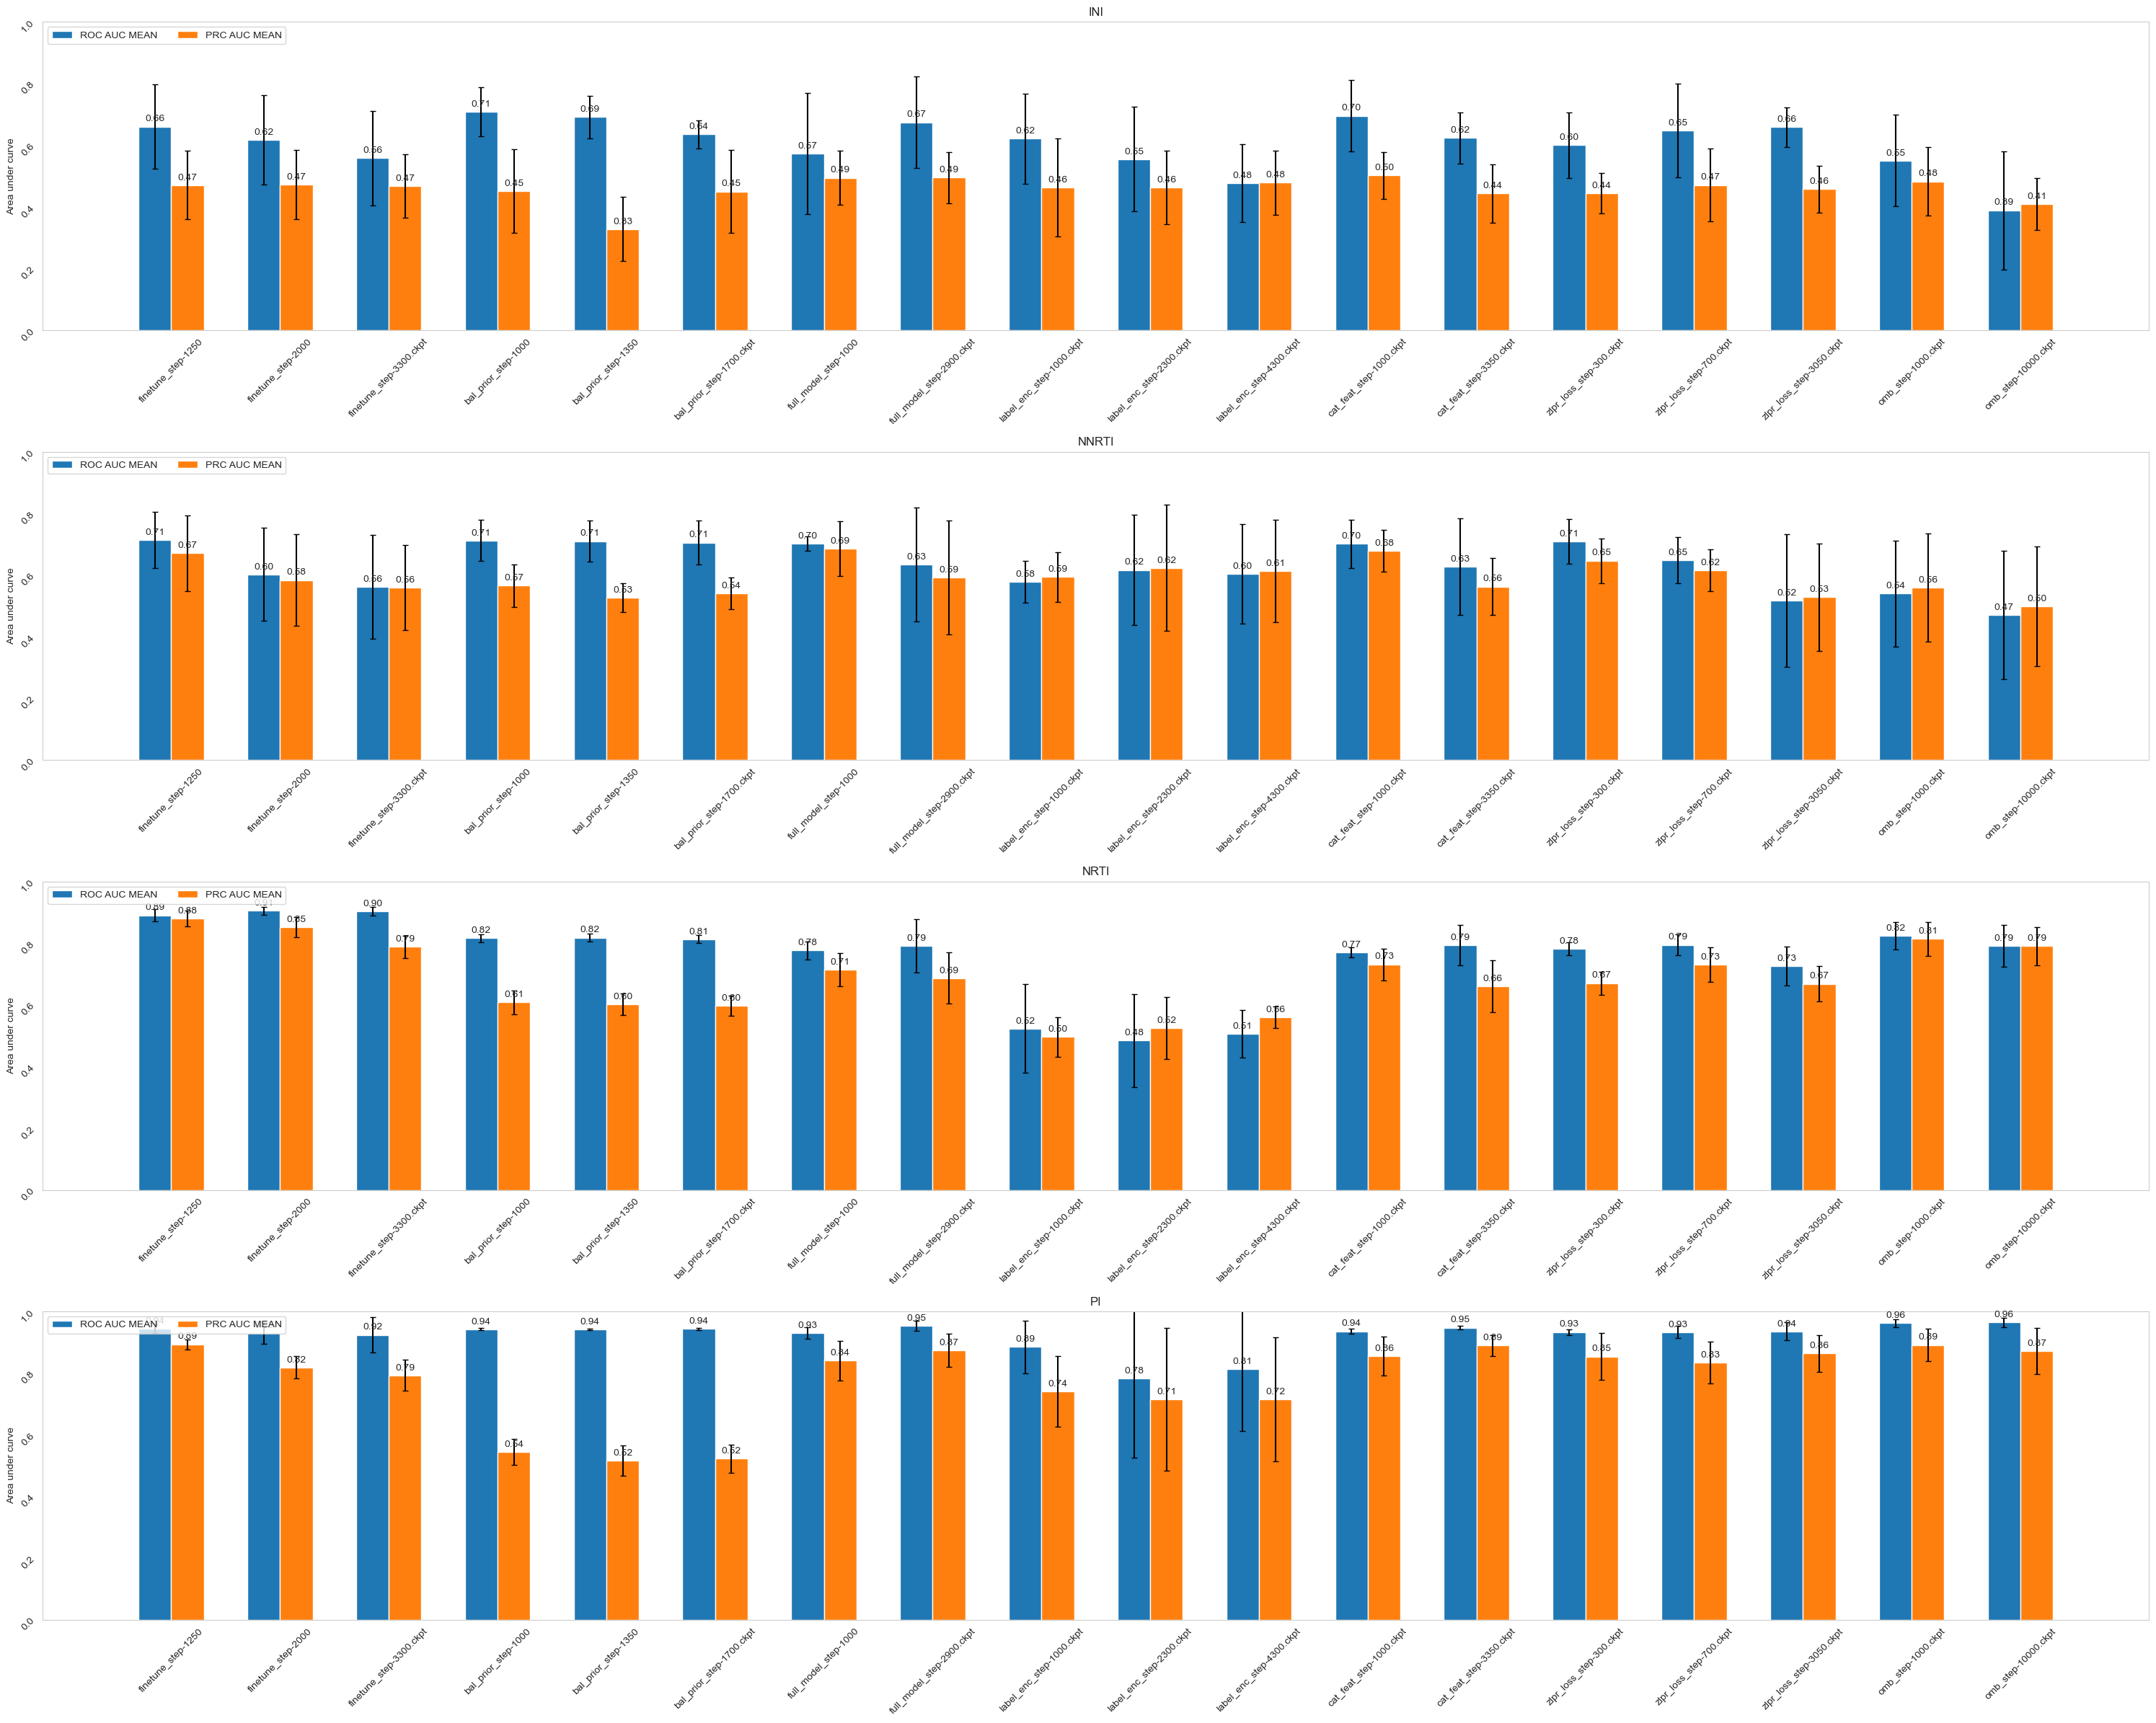

In [24]:
modeltype = "MuLaTabICL_"

models = [
    "finetune_step-1250",
    "finetune_step-2000",
    "finetune_step-3300.ckpt",
    "bal_prior_step-1000",
    "bal_prior_step-1350",
    "bal_prior_step-1700.ckpt",
    "full_model_step-1000",
    "full_model_step-2900.ckpt",
    "label_enc_step-1000.ckpt",
    "label_enc_step-2300.ckpt",
    "label_enc_step-4300.ckpt",
    "cat_feat_step-1000.ckpt",
    "cat_feat_step-3350.ckpt",
    "zlpr_loss_step-300.ckpt",
    "zlpr_loss_step-700.ckpt",
    "zlpr_loss_step-3050.ckpt",
    "omb_step-1000.ckpt",
    "omb_step-10000.ckpt"]

"""
results_mean = []
results_std = []

ending = "_5_fold_new_loss_sigmoid.csv"

#path="../prediction_results/scene.csv_results/scene.csv_"

for path in filepath_list:

    roc_auc_mean = []
    roc_auc_std = []
    prc_auc_mean = []
    prc_auc_std = []



    print("============" + path.split("/")[-1].strip("_") + "============")

    for model in models:

        print(model)

        pred_proba = pd.read_csv(path + modeltype + model.strip(".ckpt") + "_probabilities" + ending)



        roc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: roc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*"))), include_groups=False)
        prc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: result_handler.prc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*")), multiclass="ovr"), include_groups=False)


        roc_auc_mean.append(roc_auc.mean())
        roc_auc_std.append(roc_auc.std())

        prc_auc_mean.append(prc_auc.mean())
        prc_auc_std.append(prc_auc.std())

        #roc_auc.append(roc_auc_score(true_label_arr, pred_proba_arr))
        #prc_auc.append(result_handler.prc_auc_score(true_label_arr, pred_proba_arr, multiclass="ovr"))

    '''
    benchmark_prefix = re.sub('[^/]+_$', '', path) + "benchmarkings/" + path.split("/")[-1]

    #comp_mod = [benchmark_prefix + "BR_XGB_probabilities.csv", benchmark_prefix + "CC_XGB_probabilities.csv", path + "Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv", path + "Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv"]

    comp_mod = [path + "Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv", path + "Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv"]

    for model in comp_mod:

        print(model)


        pred_proba = pd.read_csv(model)

        pred_proba.dropna(subset=pred_proba.columns[pred_proba.columns.str.startswith('True_')].tolist(), inplace=True)


        roc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: roc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*"))), include_groups=False)
        prc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: result_handler.prc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*")), multiclass="ovr"), include_groups=False)


        roc_auc_mean.append(roc_auc.mean())
        roc_auc_std.append(roc_auc.std())

        prc_auc_mean.append(prc_auc.mean())
        prc_auc_std.append(prc_auc.std())
    '''


    results_mean.append({"ROC AUC MEAN":roc_auc_mean,
                    "PRC AUC MEAN":prc_auc_mean})

    results_std.append({"ROC AUC STD":roc_auc_std,
                    "PRC AUC STD":prc_auc_std})

"""
#x_ticks = models + ["BR TabPFN", "CC TabPFN"]

x_ticks = models

x = np.arange(len(x_ticks))  # the label locations
width = 0.3  # the width of the bars

fig, axs = plt.subplots(4, figsize=(30, 24),layout='tight')

for i, path in enumerate(filepath_list):

    multiplier = 0.5

    ax = axs[i]

    for attribute, measurement in results_mean[i].items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        print(results_std[i][attribute.strip("MEAN") + "STD"])
        ax.errorbar(x + offset, measurement, yerr=results_std[i][attribute.strip("MEAN") + "STD"],capsize=3, fmt="none", ecolor="black")
        ax.bar_label(rects, fmt='%.2f', padding=3)
        multiplier += 1

    ax.grid(False)

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Area under curve')
    ax.set_title(path.split("/")[-1].strip("_"))
    ax.tick_params(rotation=45)
    ax.set_xticks(x + width, x_ticks)
    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, 1)

plt.show()



============INI============
finetune_step-1250
finetune_step-2000
finetune_step-3300.ckpt
bal_prior_step-1000
bal_prior_step-1350
bal_prior_step-1700.ckpt
full_model_step-1000
full_model_step-2900.ckpt
label_enc_step-1000.ckpt
label_enc_step-2300.ckpt
label_enc_step-4300.ckpt
cat_feat_step-1000.ckpt
cat_feat_step-3350.ckpt
zlpr_loss_step-300.ckpt
zlpr_loss_step-700.ckpt
zlpr_loss_step-3050.ckpt
omb_step-1000.ckpt
omb_step-10000.ckpt
============NNRTI============
finetune_step-1250
finetune_step-2000
finetune_step-3300.ckpt
bal_prior_step-1000
bal_prior_step-1350
bal_prior_step-1700.ckpt
full_model_step-1000
full_model_step-2900.ckpt
label_enc_step-1000.ckpt
label_enc_step-2300.ckpt
label_enc_step-4300.ckpt
cat_feat_step-1000.ckpt
cat_feat_step-3350.ckpt
zlpr_loss_step-300.ckpt
zlpr_loss_step-700.ckpt
zlpr_loss_step-3050.ckpt
omb_step-1000.ckpt
omb_step-10000.ckpt
============NRTI============
finetune_step-1250
finetune_step-2000
finetune_step-3300.ckpt
bal_prior_step-1000
bal_prior_ste

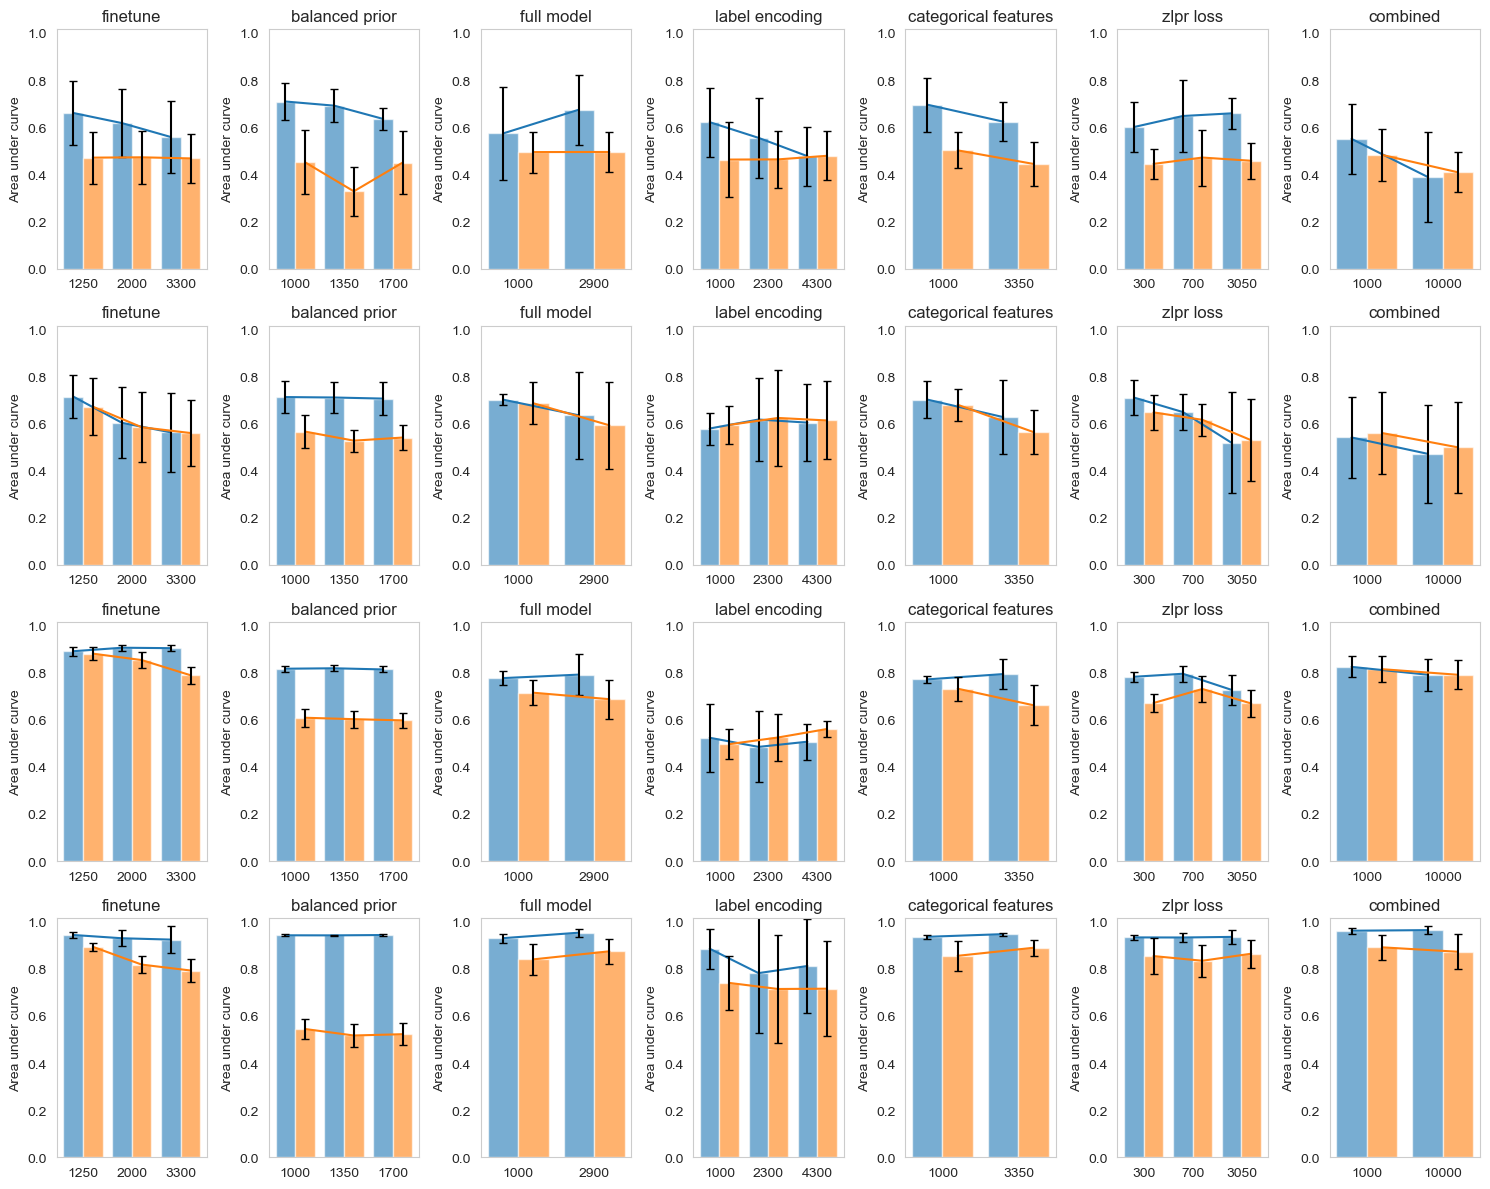

In [65]:
modeltype = "MuLaTabICL_"

models = [
    "finetune_step-1250",
    "finetune_step-2000",
    "finetune_step-3300.ckpt",
    "bal_prior_step-1000",
    "bal_prior_step-1350",
    "bal_prior_step-1700.ckpt",
    "full_model_step-1000",
    "full_model_step-2900.ckpt",
    "label_enc_step-1000.ckpt",
    "label_enc_step-2300.ckpt",
    "label_enc_step-4300.ckpt",
    "cat_feat_step-1000.ckpt",
    "cat_feat_step-3350.ckpt",
    "zlpr_loss_step-300.ckpt",
    "zlpr_loss_step-700.ckpt",
    "zlpr_loss_step-3050.ckpt",
    "omb_step-1000.ckpt",
    "omb_step-10000.ckpt"]


results_mean = []
results_std = []

ending = "_5_fold_new_loss_sigmoid.csv"

#path="../prediction_results/scene.csv_results/scene.csv_"

for path in filepath_list:

    roc_auc_mean = []
    roc_auc_std = []
    prc_auc_mean = []
    prc_auc_std = []



    print("============" + path.split("/")[-1].strip("_") + "============")

    for model in models:

        print(model)

        pred_proba = pd.read_csv(path + modeltype + model.strip(".ckpt") + "_probabilities" + ending)



        roc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: roc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*"))), include_groups=False)
        prc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: result_handler.prc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*")), multiclass="ovr"), include_groups=False)


        roc_auc_mean.append(roc_auc.mean())
        roc_auc_std.append(roc_auc.std())

        prc_auc_mean.append(prc_auc.mean())
        prc_auc_std.append(prc_auc.std())

        #roc_auc.append(roc_auc_score(true_label_arr, pred_proba_arr))
        #prc_auc.append(result_handler.prc_auc_score(true_label_arr, pred_proba_arr, multiclass="ovr"))


    benchmark_prefix = re.sub('[^/]+_$', '', path) + "benchmarkings/" + path.split("/")[-1]

    #comp_mod = [benchmark_prefix + "BR_XGB_probabilities.csv", benchmark_prefix + "CC_XGB_probabilities.csv", path + "Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv", path + "Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv"]

    """
    comp_mod = [path + "Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv", path + "Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv"]

    for model in comp_mod:

        print(model)


        pred_proba = pd.read_csv(model)

        pred_proba.dropna(subset=pred_proba.columns[pred_proba.columns.str.startswith('True_')].tolist(), inplace=True)


        roc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: roc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*"))), include_groups=False)
        prc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: result_handler.prc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*")), multiclass="ovr"), include_groups=False)


        roc_auc_mean.append(roc_auc.mean())
        roc_auc_std.append(roc_auc.std())

        prc_auc_mean.append(prc_auc.mean())
        prc_auc_std.append(prc_auc.std())
    """


    results_mean.append({"ROC AUC MEAN":roc_auc_mean,
                    "PRC AUC MEAN":prc_auc_mean})

    results_std.append({"ROC AUC STD":roc_auc_std,
                    "PRC AUC STD":prc_auc_std})


#x_ticks = models + ["BR TabPFN", "CC TabPFN"]

x_ticks = {
    "finetune":3,
    "balanced prior":3,
    "full model":2,
    "label encoding":3,
    "categorical features":2,
    "zlpr loss":3,
    "combined":2}

steps = {
    "finetune":[1250, 2000, 3300],
    "balanced prior":[1000, 1350, 1700],
    "full model": [1000, 2900],
    "label encoding":[1000, 2300, 4300],
    "categorical features":[1000, 3350],
    "zlpr loss":[300, 700, 3050],
    "combined":[1000, 10000]}

colors = {"ROC AUC MEAN":"tab:blue", "PRC AUC MEAN":"tab:orange"}

width = 0.4  # the width of the bars

fig, axs = plt.subplots(4, 7, figsize=(15, 12),layout='tight')

axs = axs.flatten()

for i, path in enumerate(filepath_list):


    j = i * 7

    l = 0 # model counter
    k = 0 # axes counter

    for model, model_num in x_ticks.items():

        multiplier = 0.5

        ax = axs[j + k]

        x = np.arange(model_num)  # the label locations

        for attribute, measurement in results_mean[i].items():
            offset = width * multiplier
            if model != "PT":
                rects = ax.bar(x + offset, measurement[l:l+model_num], width, alpha=0.6)
                ax.plot(x + offset, measurement[l:l+model_num], width, color=colors[attribute])
                #print(results_std[i][attribute.strip("MEAN") + "STD"])
                ax.errorbar(x + offset, measurement[l:l+model_num], yerr=results_std[i][attribute.strip("MEAN") + "STD"][l:l+model_num],capsize=3, fmt="none", ecolor="black")
                #ax.bar_label(rects, fmt='%.3f', padding=12)
            multiplier += 1

        ax.grid(False)

        # Add some text for labels, title and custom x-axis tick labels, etc.
        ax.set_ylabel('Area under curve')
        ax.set_title(model)
        #ax.tick_params(rotation=45)
        ax.set_xticks(x + width, steps[model])
        #ax.legend(loc='upper left', ncols=3)
        ax.set_ylim(0, 1.015)

        l += model_num
        k += 1

plt.savefig("../figures/09_det_perf/det_perf_auc_new.png")



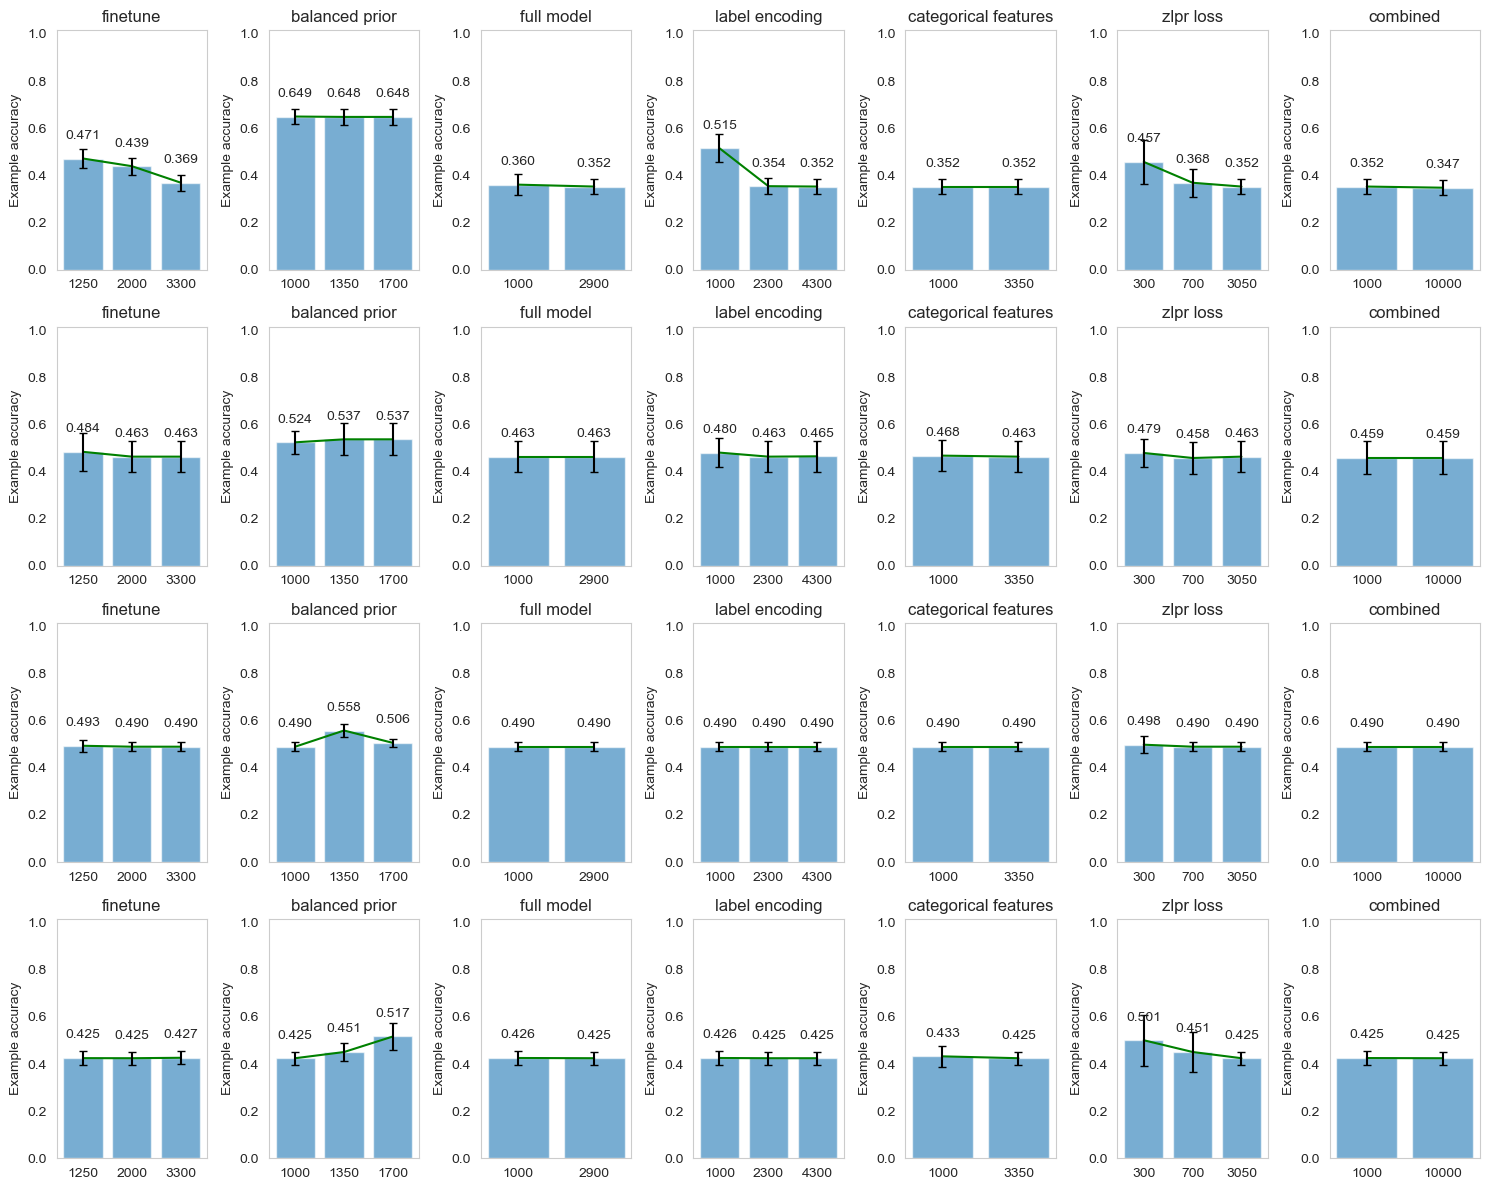

In [10]:
modeltype = "MuLaTabICL_"

models = [
    "finetune_step-1250",
    "finetune_step-2000",
    "finetune_step-3300.ckpt",
    "bal_prior_step-1000",
    "bal_prior_step-1350",
    "bal_prior_step-1700.ckpt",
    "full_model_step-1000",
    "full_model_step-2900.ckpt",
    "label_enc_step-1000.ckpt",
    "label_enc_step-2300.ckpt",
    "label_enc_step-4300.ckpt",
    "cat_feat_step-1000.ckpt",
    "cat_feat_step-3350.ckpt",
    "zlpr_loss_step-300.ckpt",
    "zlpr_loss_step-700.ckpt",
    "zlpr_loss_step-3050.ckpt",
    "omb_step-1000.ckpt",
    "omb_step-10000.ckpt"]

'''
results_mean = []
results_std = []

ending = "_5_fold_new_loss_sigmoid.csv"

#path="../prediction_results/scene.csv_results/scene.csv_"

for path in filepath_list:

    roc_auc_mean = []
    roc_auc_std = []


    print("============" + path.split("/")[-1].strip("_") + "============")

    for model in models:

        print(model)

        pred_proba = pd.read_csv(path + modeltype + model.strip(".ckpt") + ending)



        roc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: result_handler.exam_acc(x.filter(regex="True_*"), x.filter(regex="Pred_*")), include_groups=False)



        roc_auc_mean.append(roc_auc.mean())
        roc_auc_std.append(roc_auc.std())


        #roc_auc.append(roc_auc_score(true_label_arr, pred_proba_arr))
        #prc_auc.append(result_handler.prc_auc_score(true_label_arr, pred_proba_arr, multiclass="ovr"))


    benchmark_prefix = re.sub('[^/]+_$', '', path) + "benchmarkings/" + path.split("/")[-1]

    #comp_mod = [benchmark_prefix + "BR_XGB_probabilities.csv", benchmark_prefix + "CC_XGB_probabilities.csv", path + "Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv", path + "Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv"]

    """

    comp_mod = [path + "Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv", path + "Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv"]

    for model in comp_mod:

        print(model)


        pred_proba = pd.read_csv(model)

        pred_proba.dropna(subset=pred_proba.columns[pred_proba.columns.str.startswith('True_')].tolist(), inplace=True)


        roc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: roc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*"))), include_groups=False)
        prc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: result_handler.prc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*")), multiclass="ovr"), include_groups=False)


        roc_auc_mean.append(roc_auc.mean())
        roc_auc_std.append(roc_auc.std())

        prc_auc_mean.append(prc_auc.mean())
        prc_auc_std.append(prc_auc.std())
    """


    results_mean.append(roc_auc_mean)

    results_std.append(roc_auc_std)

'''
#x_ticks = models + ["BR TabPFN", "CC TabPFN"]

x_ticks = {
    "finetune":3,
    "balanced prior":3,
    "full model":2,
    "label encoding":3,
    "categorical features":2,
    "zlpr loss":3,
    "combined":2}

steps = {
    "finetune":[1250, 2000, 3300],
    "balanced prior":[1000, 1350, 1700],
    "full model": [1000, 2900],
    "label encoding":[1000, 2300, 4300],
    "categorical features":[1000, 3350],
    "zlpr loss":[300, 700, 3050],
    "combined":[1000, 10000]}

colors = {"ROC AUC MEAN":"tab:blue", "PRC AUC MEAN":"tab:orange"}

width = 0.4  # the width of the bars

fig, axs = plt.subplots(4, 7, figsize=(15, 12),layout='tight')

axs = axs.flatten()

for i, path in enumerate(filepath_list):


    j = i * 7

    l = 0 # model counter
    k = 0 # axes counter

    for model, model_num in x_ticks.items():



        ax = axs[j + k]

        x = np.arange(model_num)  # the label locations


        rects = ax.bar(x, results_mean[i][l:l+model_num], alpha=0.6)
        ax.plot(x, results_mean[i][l:l+model_num], color="g")
        #print(results_std[i][attribute.strip("MEAN") + "STD"])
        ax.errorbar(x, results_mean[i][l:l+model_num], yerr=results_std[i][l:l+model_num],capsize=3, fmt="none", ecolor="black")
        ax.bar_label(rects, fmt='%.3f', padding=12)

        ax.grid(False)

        # Add some text for labels, title and custom x-axis tick labels, etc.
        ax.set_ylabel('Example accuracy')
        ax.set_title(model)
        #ax.tick_params(rotation=45)
        ax.set_xticks(x, steps[model])
        #ax.legend(loc='upper left', ncols=3)
        ax.set_ylim(0, 1.015)

        l += model_num
        k += 1

#plt.savefig("../figures/09_det_perf/det_perf_auc_new.png")



## TabPFN learns to predict datasets

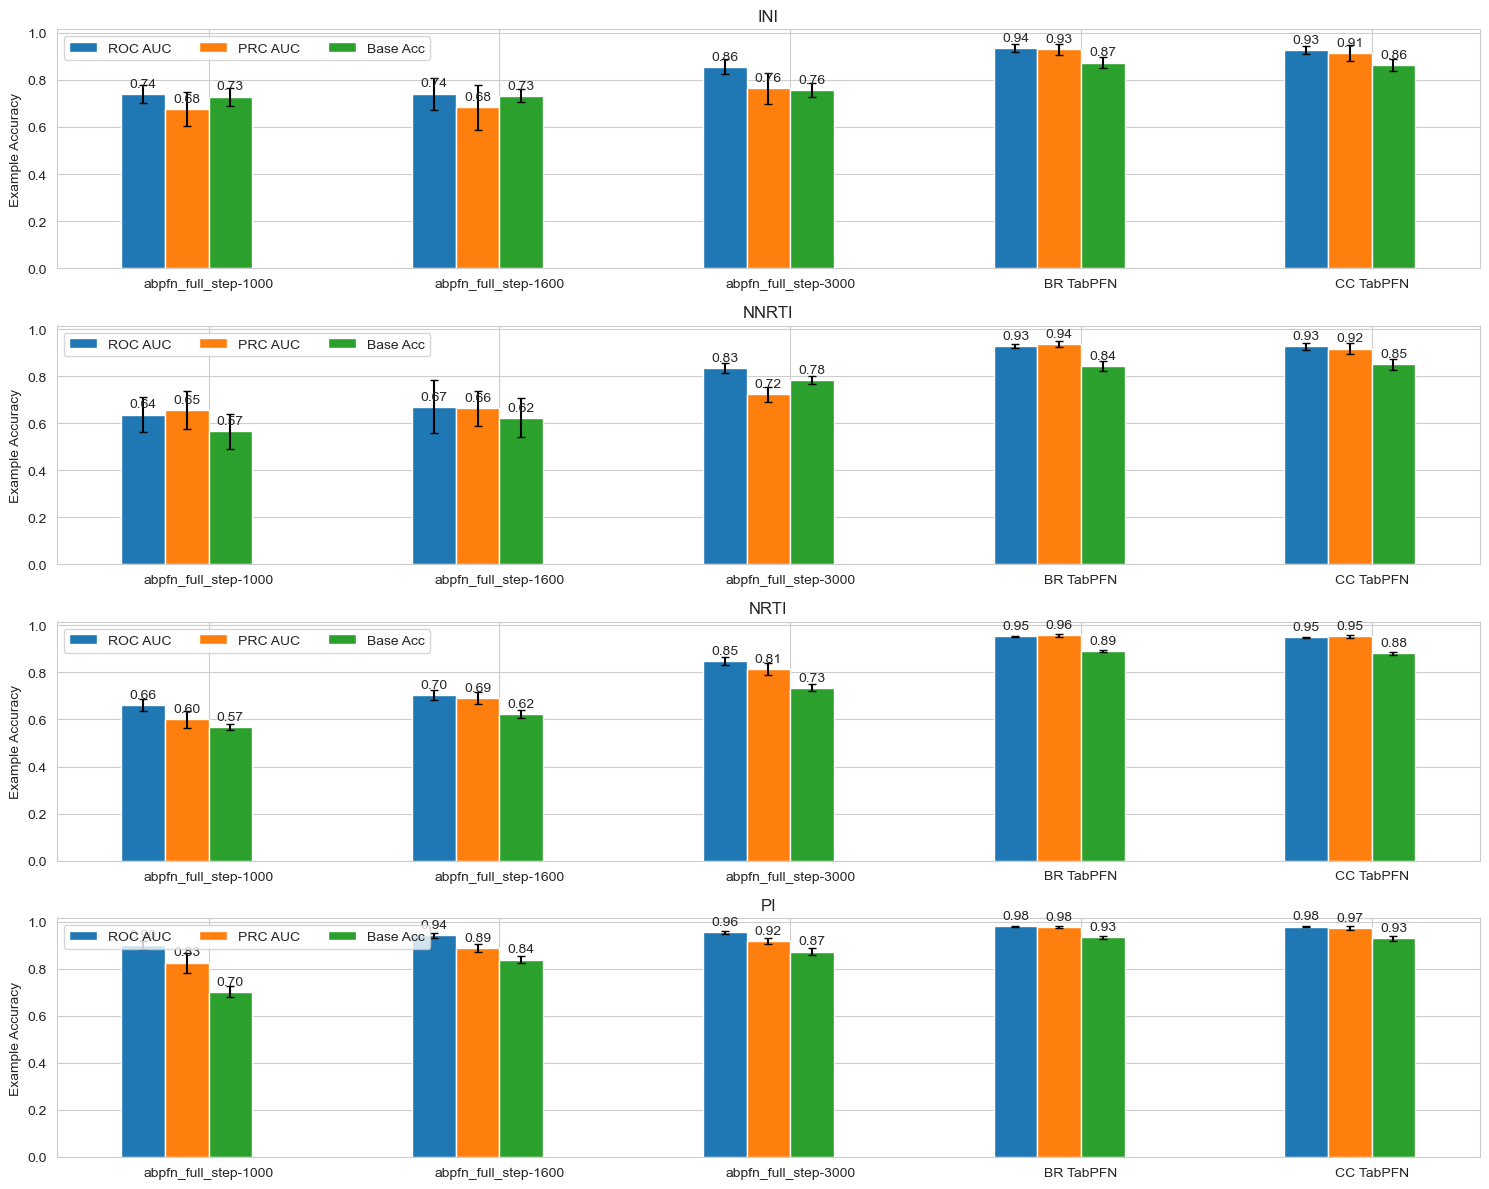

In [26]:


import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import prediction_handler as result_handler
import os
from sklearn.metrics import jaccard_score, roc_auc_score
import result_handler


modeltype = "MuLaTabICL_"

models = [
    "abpfn_full_step-1000",
    "abpfn_full_step-1600",
    "abpfn_full_step-3000"]

ending = "_5_fold_new_loss_sigmoid.csv"

"""

results_mean = []

results_std = []


#path="../prediction_results/scene.csv_results/scene.csv_"



for path in filepath_list:

    print("============" + path.split("/")[-1].strip("_") + "============")

    roc_auc_mean = []
    prc_auc_mean = []
    old_acc_mean = []

    roc_auc_std = []
    prc_auc_std = []
    old_acc_std = []

    for model in models:

        print(model)

        pred = pd.read_csv(path + modeltype + model + ending)
        pred_proba = pd.read_csv(path + modeltype + model + "_probabilities" + ending)

        pred_proba.dropna(subset=pred_proba.columns[pred_proba.columns.str.startswith('True_')].tolist(), inplace=True)
        pred.dropna(subset=pred_proba.columns[pred_proba.columns.str.startswith('True_')].tolist(), inplace=True)


        roc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: roc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*"))), include_groups=False)
        prc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: result_handler.prc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*")), multiclass="ovr"), include_groups=False)
        old_acc = pred.groupby(by="kFolds").apply(lambda x: result_handler.exam_acc(x.filter(regex="True_*"), x.filter(regex="Pred_*")), include_groups=False)

        roc_auc_mean.append(roc_auc.mean())
        roc_auc_std.append(roc_auc.std())

        prc_auc_mean.append(prc_auc.mean())
        prc_auc_std.append(prc_auc.std())

        old_acc_groups = pred.groupby(by="kFolds").apply(
        lambda x: result_handler.exam_acc(x.filter(regex="True_*"), x.filter(regex="Pred_*")),
        include_groups=False)

        old_acc_mean.append(old_acc_groups.mean())
        old_acc_std.append(old_acc_groups.std())

    comp_mod = [path + "Binary_Relevance_probabilities_5_fold_MOC_prediction_new_save.csv", path + "Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv"]

    for model in comp_mod:

        print(model)


        pred_proba = pd.read_csv(model)

        pred_proba.dropna(subset=pred_proba.columns[pred_proba.columns.str.startswith('True_')].tolist(), inplace=True)

        pred = (pred_proba > 0.5) * 1.0

        pred["kFolds"] = pred_proba["kFolds"]

        roc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: roc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*"))), include_groups=False)
        prc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: result_handler.prc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*")), multiclass="ovr"), include_groups=False)


        roc_auc_mean.append(roc_auc.mean())
        roc_auc_std.append(roc_auc.std())

        prc_auc_mean.append(prc_auc.mean())
        prc_auc_std.append(prc_auc.std())

        old_acc_groups = pred.groupby(by="kFolds").apply(
        lambda x: result_handler.exam_acc(x.filter(regex="True_*"), x.filter(regex="Pred_*")),
        include_groups=False)

        old_acc_mean.append(old_acc_groups.mean())
        old_acc_std.append(old_acc_groups.std())

    model_results_mean = {"ROC AUC":roc_auc_mean,
                             "PRC AUC":prc_auc_mean,
                             "Base Acc": old_acc_mean,}

    model_results_std = {"ROC AUC":roc_auc_std,
                         "PRC AUC":prc_auc_std,
                         "Base Acc": old_acc_std,}

    results_mean.append(model_results_mean)
    results_std.append(model_results_std)


"""

x_ticks = models + ["BR TabPFN", "CC TabPFN"]

x = np.arange(len(x_ticks))  # the label locations
width = 0.15  # the width of the bars

fig, axs = plt.subplots(4, figsize=(15, 12),layout='tight')

for i, path in enumerate(filepath_list):

    multiplier = -0.5

    ax = axs[i]

    for attribute, measurement in results_mean[i].items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, fmt='%.2f', padding=3)
        ax.errorbar(x + offset, measurement, yerr=results_std[i][attribute],capsize=3, fmt="none", ecolor="black")
        multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Example Accuracy')
    ax.set_title(path.split("/")[-1].strip("_"))
    ax.set_xticks(x + width, x_ticks)
    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, 1.015)

plt.show()

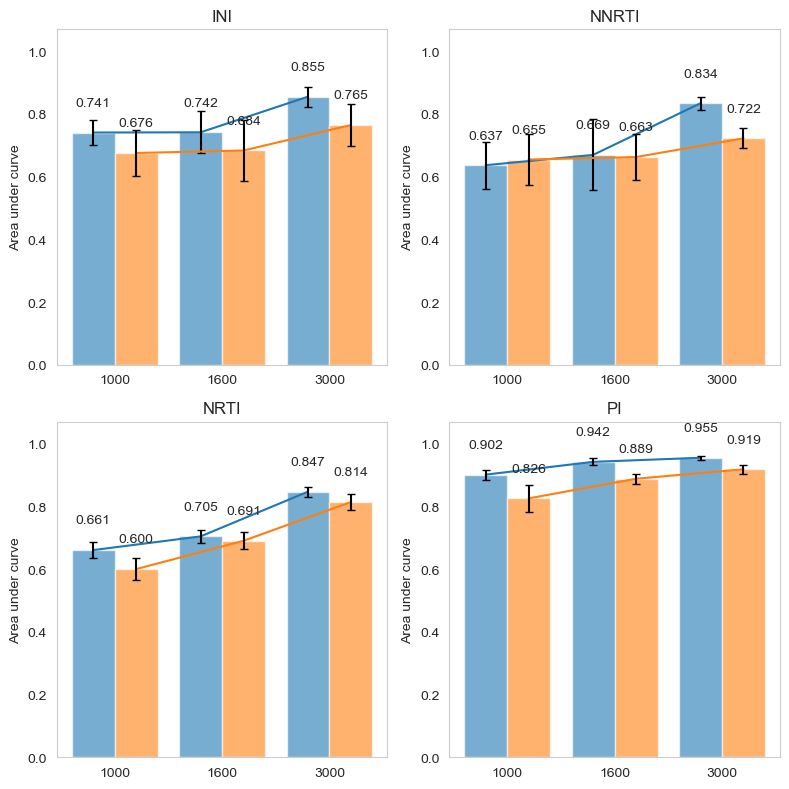

In [52]:


import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import prediction_handler as result_handler
import os
from sklearn.metrics import jaccard_score, roc_auc_score
import result_handler


modeltype = "MuLaTabICL_"

models = [
    "abpfn_full_step-1000",
    "abpfn_full_step-1600",
    "abpfn_full_step-3000"]

ending = "_5_fold_new_loss_sigmoid.csv"

'''

results_mean = []

results_std = []


#path="../prediction_results/scene.csv_results/scene.csv_"



for path in filepath_list:

    print("============" + path.split("/")[-1].strip("_") + "============")

    roc_auc_mean = []
    prc_auc_mean = []
    old_acc_mean = []

    roc_auc_std = []
    prc_auc_std = []
    old_acc_std = []

    for model in models:

        print(model)

        pred = pd.read_csv(path + modeltype + model + ending)
        pred_proba = pd.read_csv(path + modeltype + model + "_probabilities" + ending)

        pred_proba.dropna(subset=pred_proba.columns[pred_proba.columns.str.startswith('True_')].tolist(), inplace=True)
        pred.dropna(subset=pred_proba.columns[pred_proba.columns.str.startswith('True_')].tolist(), inplace=True)


        roc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: roc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*"))), include_groups=False)
        prc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: result_handler.prc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*")), multiclass="ovr"), include_groups=False)
        old_acc = pred.groupby(by="kFolds").apply(lambda x: result_handler.exam_acc(x.filter(regex="True_*"), x.filter(regex="Pred_*")), include_groups=False)

        roc_auc_mean.append(roc_auc.mean())
        roc_auc_std.append(roc_auc.std())

        prc_auc_mean.append(prc_auc.mean())
        prc_auc_std.append(prc_auc.std())

        old_acc_groups = pred.groupby(by="kFolds").apply(
        lambda x: result_handler.exam_acc(x.filter(regex="True_*"), x.filter(regex="Pred_*")),
        include_groups=False)

        old_acc_mean.append(old_acc_groups.mean())
        old_acc_std.append(old_acc_groups.std())
    """
    comp_mod = [path + "Binary_Relevance_probabilities_5_fold_MOC_prediction_new_save.csv", path + "Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv"]

    for model in comp_mod:

        print(model)


        pred_proba = pd.read_csv(model)

        pred_proba.dropna(subset=pred_proba.columns[pred_proba.columns.str.startswith('True_')].tolist(), inplace=True)

        pred = (pred_proba > 0.5) * 1.0

        pred["kFolds"] = pred_proba["kFolds"]

        roc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: roc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*"))), include_groups=False)
        prc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: result_handler.prc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*")), multiclass="ovr"), include_groups=False)


        roc_auc_mean.append(roc_auc.mean())
        roc_auc_std.append(roc_auc.std())

        prc_auc_mean.append(prc_auc.mean())
        prc_auc_std.append(prc_auc.std())

        old_acc_groups = pred.groupby(by="kFolds").apply(
        lambda x: result_handler.exam_acc(x.filter(regex="True_*"), x.filter(regex="Pred_*")),
        include_groups=False)

        old_acc_mean.append(old_acc_groups.mean())
        old_acc_std.append(old_acc_groups.std())
    """

    model_results_mean = {"ROC AUC":roc_auc_mean,
                             "PRC AUC":prc_auc_mean,}

    model_results_std = {"ROC AUC":roc_auc_std,
                         "PRC AUC":prc_auc_std,}

    results_mean.append(model_results_mean)
    results_std.append(model_results_std)

'''


x_ticks = [1000, 1600, 3000]

colors = {"ROC AUC":"tab:blue", "PRC AUC":"tab:orange"}

x = np.arange(len(x_ticks))  # the label locations
width = 0.4  # the width of the bars

fig, axs = plt.subplots(2, 2, figsize=(8, 8),layout='tight')

axs = axs.flatten()

for i, path in enumerate(filepath_list):

    multiplier = 0.5

    ax = axs[i]

    for attribute, measurement in results_mean[i].items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute, alpha=0.6)
        ax.plot(x + offset, measurement, width, color=colors[attribute])
        ax.bar_label(rects, fmt='%.3f', padding=17)
        ax.errorbar(x + offset, measurement, yerr=results_std[i][attribute],capsize=3, fmt="none", ecolor="black")
        multiplier += 1

    ax.grid(False)
    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Area under curve')
    ax.set_title(path.split("/")[-1].strip("_"))
    ax.set_xticks(x + width, x_ticks)
    #ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, 1.07)

plt.savefig("../figures/10_TabPFN/incr_perf_auc.png")

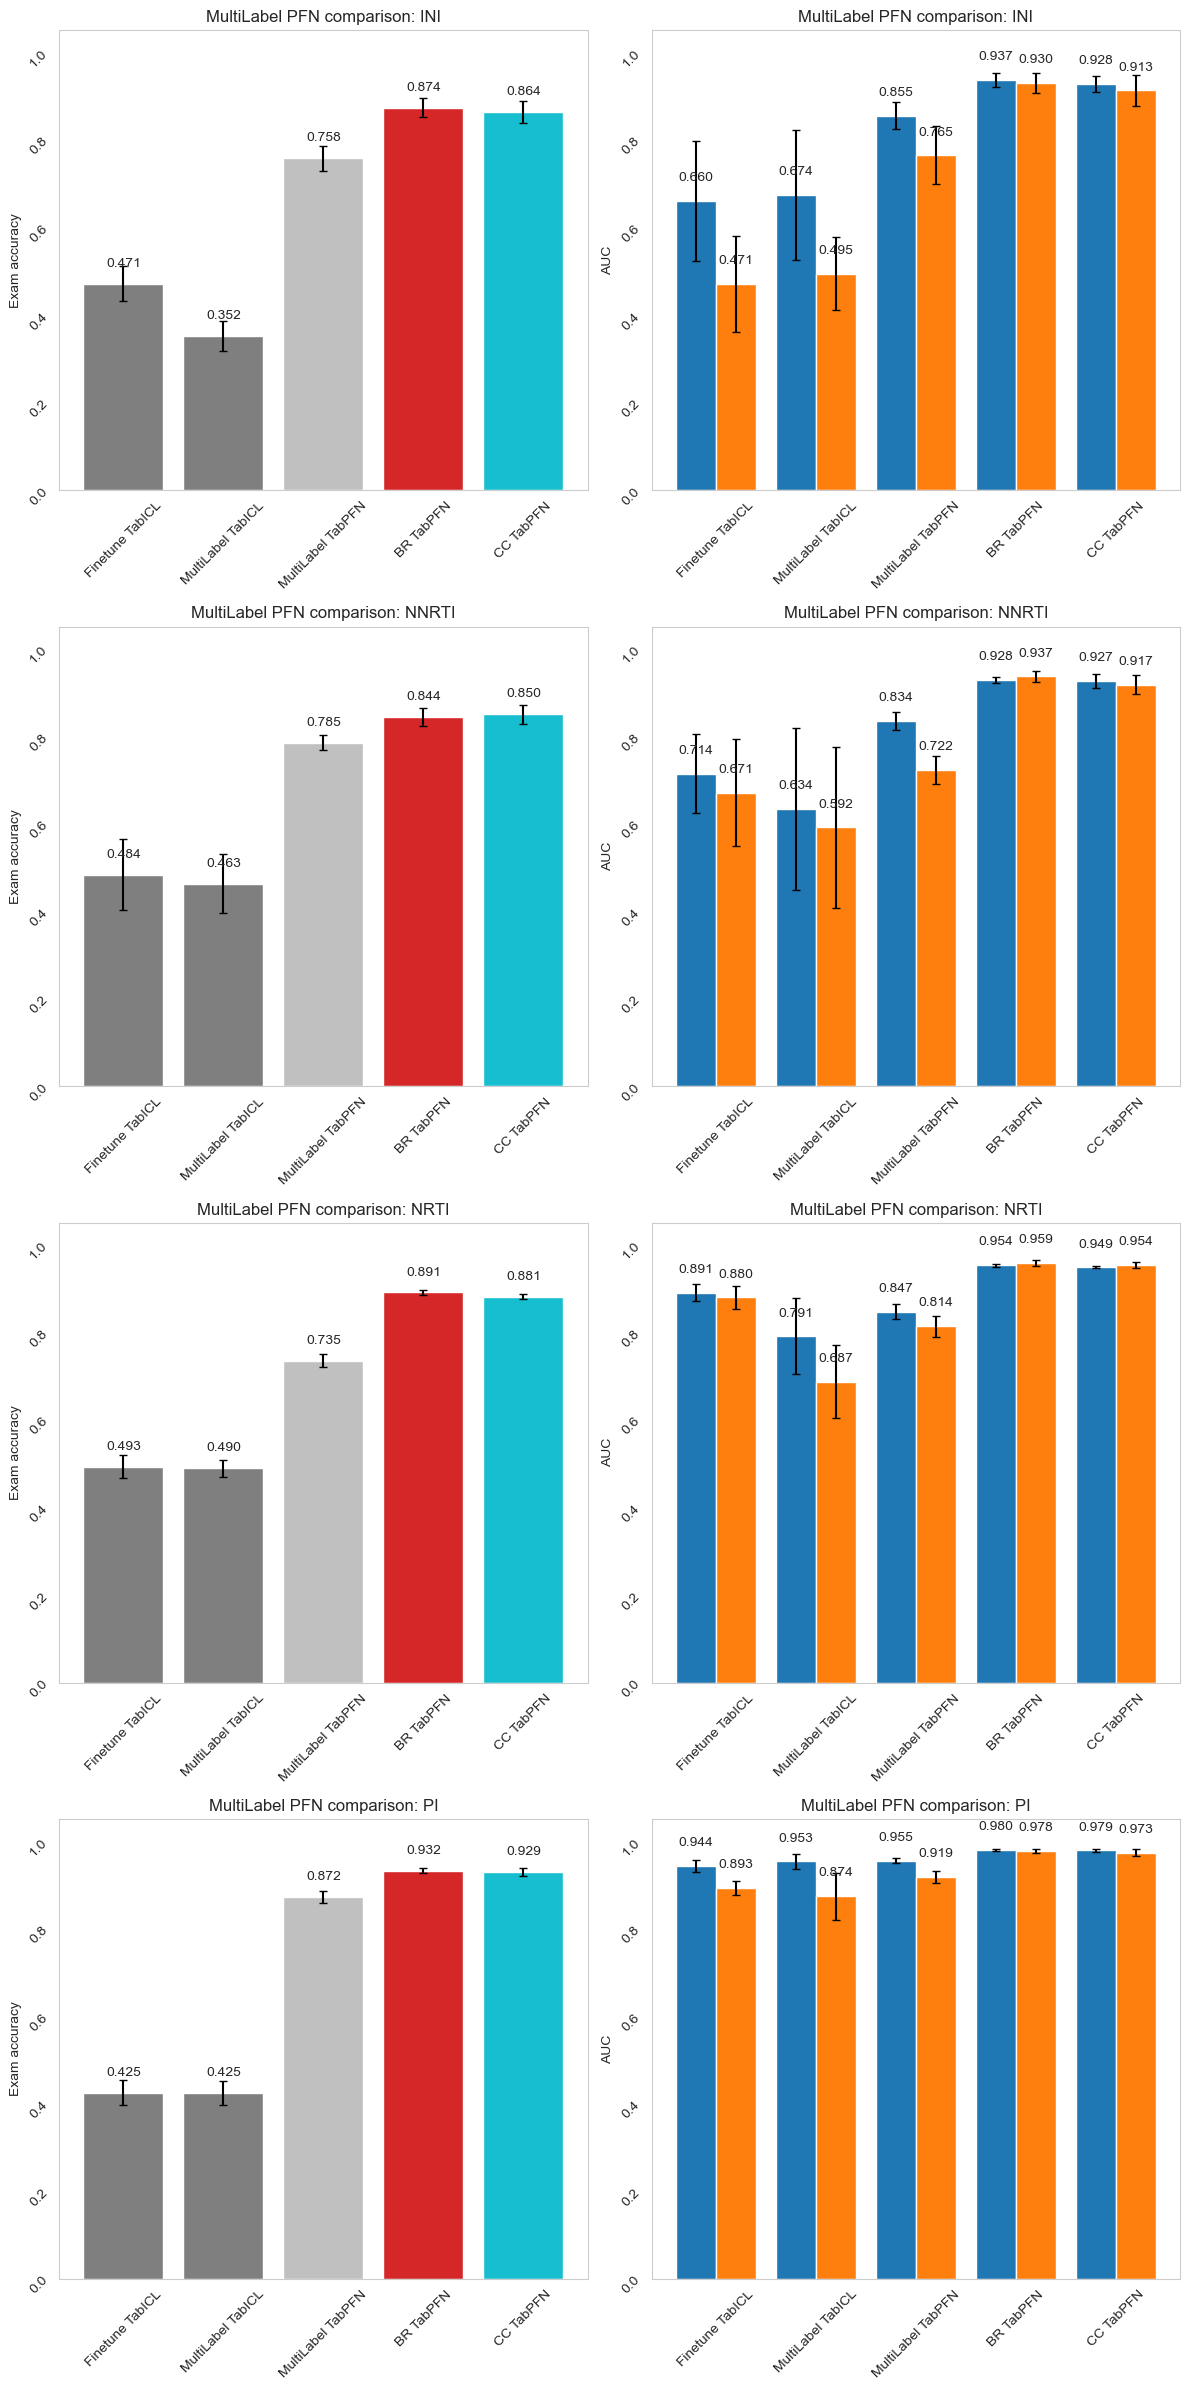

In [69]:
files = ["MuLaTabICL_finetune_step-1250_5_fold_new_loss_sigmoid.csv", "MuLaTabICL_full_model_step-2900_5_fold_new_loss_sigmoid.csv", "MuLaTabICL_abpfn_full_step-3000_5_fold_new_loss_sigmoid.csv", "Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_woNaN_new_save.csv"]



tmp_sub_accs_fold_mean, tmp_sub_accs_fold_std = result_handler.calc_metrics(filepath_list, files, result_handler.exam_acc,metric_args={}, drop_na=True)

df_sub_accs_groups_mean = pd.DataFrame(tmp_sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(tmp_sub_accs_fold_std)


files = ["MuLaTabICL_finetune_step-1250_probabilities_5_fold_new_loss_sigmoid.csv", "MuLaTabICL_full_model_step-2900_probabilities_5_fold_new_loss_sigmoid.csv","MuLaTabICL_abpfn_full_step-3000_probabilities_5_fold_new_loss_sigmoid.csv", "Binary_Relevance_probabilities_5_fold_MOC_prediction_new_save.csv", "Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv"]

tmp_roc_auc_mean, tmp_roc_auc_std = result_handler.calc_metrics(filepath_list, files, roc_auc_score,metric_args={"average": "macro"}, drop_na=True)

df_roc_auc_mean = pd.DataFrame(tmp_roc_auc_mean)
df_roc_auc_std = pd.DataFrame(tmp_roc_auc_std)

tmp_prc_auc_mean, tmp_prc_auc_std = result_handler.calc_metrics(filepath_list, files, result_handler.prc_auc_score,metric_args={"multiclass":"ovr"}, drop_na=True)

df_prc_auc_mean = pd.DataFrame(tmp_prc_auc_mean)
df_prc_auc_std = pd.DataFrame(tmp_prc_auc_std)


models_w_TabPFN = ["Finetune TabICL","MultiLabel TabICL", "MultiLabel TabPFN", "BR TabPFN", "CC TabPFN"]

color = ["tab:grey"] * 2 + ["silver"] + ["tab:red"]  + ["tab:cyan"]

labels = models_w_TabPFN

x = np.arange(len(labels))  # the label locations
width = 0.4  # the width of the bars

fig, axs = plt.subplots(4, 2, figsize=(12, 24))
#fig.tight_layout()

axs = axs.flatten()

means = []

for i, drug in enumerate(df_prc_auc_mean.columns.values.tolist()):

    j = i * 2

    p = axs[j].bar(models_w_TabPFN, df_sub_accs_groups_mean[drug], color=color)
    axs[j].errorbar(models_w_TabPFN, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")

    axs[j].bar_label(p, label_type="edge", fmt='%.3f', padding=10)

    axs[j].grid(False)
    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[j].tick_params(rotation=45)
    axs[j].set_ylabel('Exam accuracy')
    axs[j].set_ylim(0, 1.05)
    axs[j].set_title('MultiLabel PFN comparison: ' + drug)

    multiplier = -0.5

    offset = width * multiplier
    rects = axs[j + 1].bar(x + offset, df_roc_auc_mean[drug], width, label="ROC AUC")
    axs[j + 1].bar_label(rects, fmt='%.3f', padding=12)
    axs[j + 1].errorbar(x + offset, df_roc_auc_mean[drug], yerr=df_roc_auc_std[drug],capsize=3, fmt="none", ecolor="black")
    multiplier += 1

    offset = width * multiplier
    rects2 = axs[j + 1].bar(x + offset, df_prc_auc_mean[drug], width, label="PRC AUC")
    axs[j + 1].bar_label(rects2, fmt='%.3f', padding=12)
    axs[j + 1].errorbar(x + offset, df_prc_auc_mean[drug], yerr=df_prc_auc_std[drug],capsize=3, fmt="none", ecolor="black")

    multiplier += 1


    #axs[i].bar_label(p, label_type="edge", padding=10, fmt="%.3f")
    axs[j + 1].grid(False)
    axs[j + 1].set_xticks(x)
    axs[j + 1].set_xticklabels(models_w_TabPFN)
    axs[j + 1].tick_params(rotation=45)
    axs[j + 1].set_ylabel('AUC')
    axs[j+1].set_ylim(0, 1.05)
    axs[j + 1].set_title('MultiLabel PFN comparison: ' + drug)

fig.tight_layout()

#plt.show()

plt.savefig("../figures/10_TabPFN/Comparison_w_others.png")

In [ ]:



modeltype = "MuLaTabICL_"

models = [
    "finetune_step-1250.ckpt",
    "finetune_stage3_step-50",
    "bal_prior_step-1000.ckpt",
    "full_model_step-1000.ckpt",
    "label_enc_step-1000.ckpt",
    "cat_feat_step-1000.ckpt",
    "zlpr_loss_step-700.ckpt",
    "omb_step-1000.ckpt"]

"""

results_mean = []
results_std = []

ending = "_5_fold_new_loss_sigmoid.csv"

#path="../prediction_results/scene.csv_results/scene.csv_"

for path in filepath_list:

    roc_auc_mean = []
    roc_auc_std = []
    prc_auc_mean = []
    prc_auc_std = []



    print("============" + path.split("/")[-1].strip("_") + "============")

    for model in models:

        print(model)

        pred_proba = pd.read_csv(path + modeltype + model.strip(".ckpt") + "_probabilities" + ending)



        roc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: roc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*"))), include_groups=False)
        prc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: result_handler.prc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*")), multiclass="ovr"), include_groups=False)


        roc_auc_mean.append(roc_auc.mean())
        roc_auc_std.append(roc_auc.std())

        prc_auc_mean.append(prc_auc.mean())
        prc_auc_std.append(prc_auc.std())

        #roc_auc.append(roc_auc_score(true_label_arr, pred_proba_arr))
        #prc_auc.append(result_handler.prc_auc_score(true_label_arr, pred_proba_arr, multiclass="ovr"))


    benchmark_prefix = re.sub('[^/]+_$', '', path) + "benchmarkings/" + path.split("/")[-1]

    #comp_mod = [benchmark_prefix + "BR_XGB_probabilities.csv", benchmark_prefix + "CC_XGB_probabilities.csv", path + "Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv", path + "Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv"]

    comp_mod = [path + "Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv"]

    for model in comp_mod:

        print(model)


        pred_proba = pd.read_csv(model)

        pred_proba.dropna(subset=pred_proba.columns[pred_proba.columns.str.startswith('True_')].tolist(), inplace=True)


        roc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: roc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*"))), include_groups=False)
        prc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: result_handler.prc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*")), multiclass="ovr"), include_groups=False)


        roc_auc_mean.append(roc_auc.mean())
        roc_auc_std.append(roc_auc.std())

        prc_auc_mean.append(prc_auc.mean())
        prc_auc_std.append(prc_auc.std())

    '''
    model_results= {"ROC AUC MEAN":roc_auc_mean,
                    "ROC AUC STD":roc_auc_std,
                    "PRC AUC MEAN":prc_auc_mean,
                    "PRC AUC STD":prc_auc_std}
    '''

    results_mean.append({"ROC AUC MEAN":roc_auc_mean,
                    "PRC AUC MEAN":prc_auc_mean})

    results_std.append({"ROC AUC STD":roc_auc_std,
                    "PRC AUC STD":prc_auc_std})

"""
x_ticks = [
    "finetune",
    "finetune small",
    "balanced prior",
    "full model",
    "label encoding",
    "categorical features",
    "zlpr loss",
    "combined"] + ["BR TabPFN"]

x = np.arange(len(x_ticks))  # the label locations
width = 0.4  # the width of the bars

fig, axs = plt.subplots(2, 2, figsize=(18, 14),layout='tight')

axs = axs.flatten()

for i, path in enumerate(filepath_list):

    multiplier = 0.5

    ax = axs[i]

    for attribute, measurement in results_mean[i].items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        print(results_std[i][attribute.strip("MEAN") + "STD"])
        ax.errorbar(x + offset, measurement, yerr=results_std[i][attribute.strip("MEAN") + "STD"],capsize=3, fmt="none", ecolor="black")
        ax.bar_label(rects, fmt='%.3f', padding=8)
        multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Area under curve')
    ax.set_title(path.split("/")[-1].strip("_"))
    ax.tick_params(rotation=45)
    ax.set_xticks(x + width, x_ticks)
    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, 1.07)

#plt.show()

plt.savefig("../figures/10_TabPFN/diff_mod_comp_auc.png")

============INI============
finetune_step-1250
bal_prior_step-1000
finetune_step-2000
bal_prior_step-1000
full_model_step-1000
zlpr_loss_step-300
omb_step-10000
abpfn_full_step-1000
abpfn_full_step-1600
abpfn_full_step-3000
============NNRTI============
finetune_step-1250
bal_prior_step-1000
finetune_step-2000
bal_prior_step-1000
full_model_step-1000
zlpr_loss_step-300
omb_step-10000
abpfn_full_step-1000
abpfn_full_step-1600
abpfn_full_step-3000
============NRTI============
finetune_step-1250
bal_prior_step-1000
finetune_step-2000
bal_prior_step-1000
full_model_step-1000
zlpr_loss_step-300
omb_step-10000
abpfn_full_step-1000
abpfn_full_step-1600
abpfn_full_step-3000
============PI============
finetune_step-1250
bal_prior_step-1000
finetune_step-2000
bal_prior_step-1000
full_model_step-1000
zlpr_loss_step-300
omb_step-10000
abpfn_full_step-1000
abpfn_full_step-1600
abpfn_full_step-3000


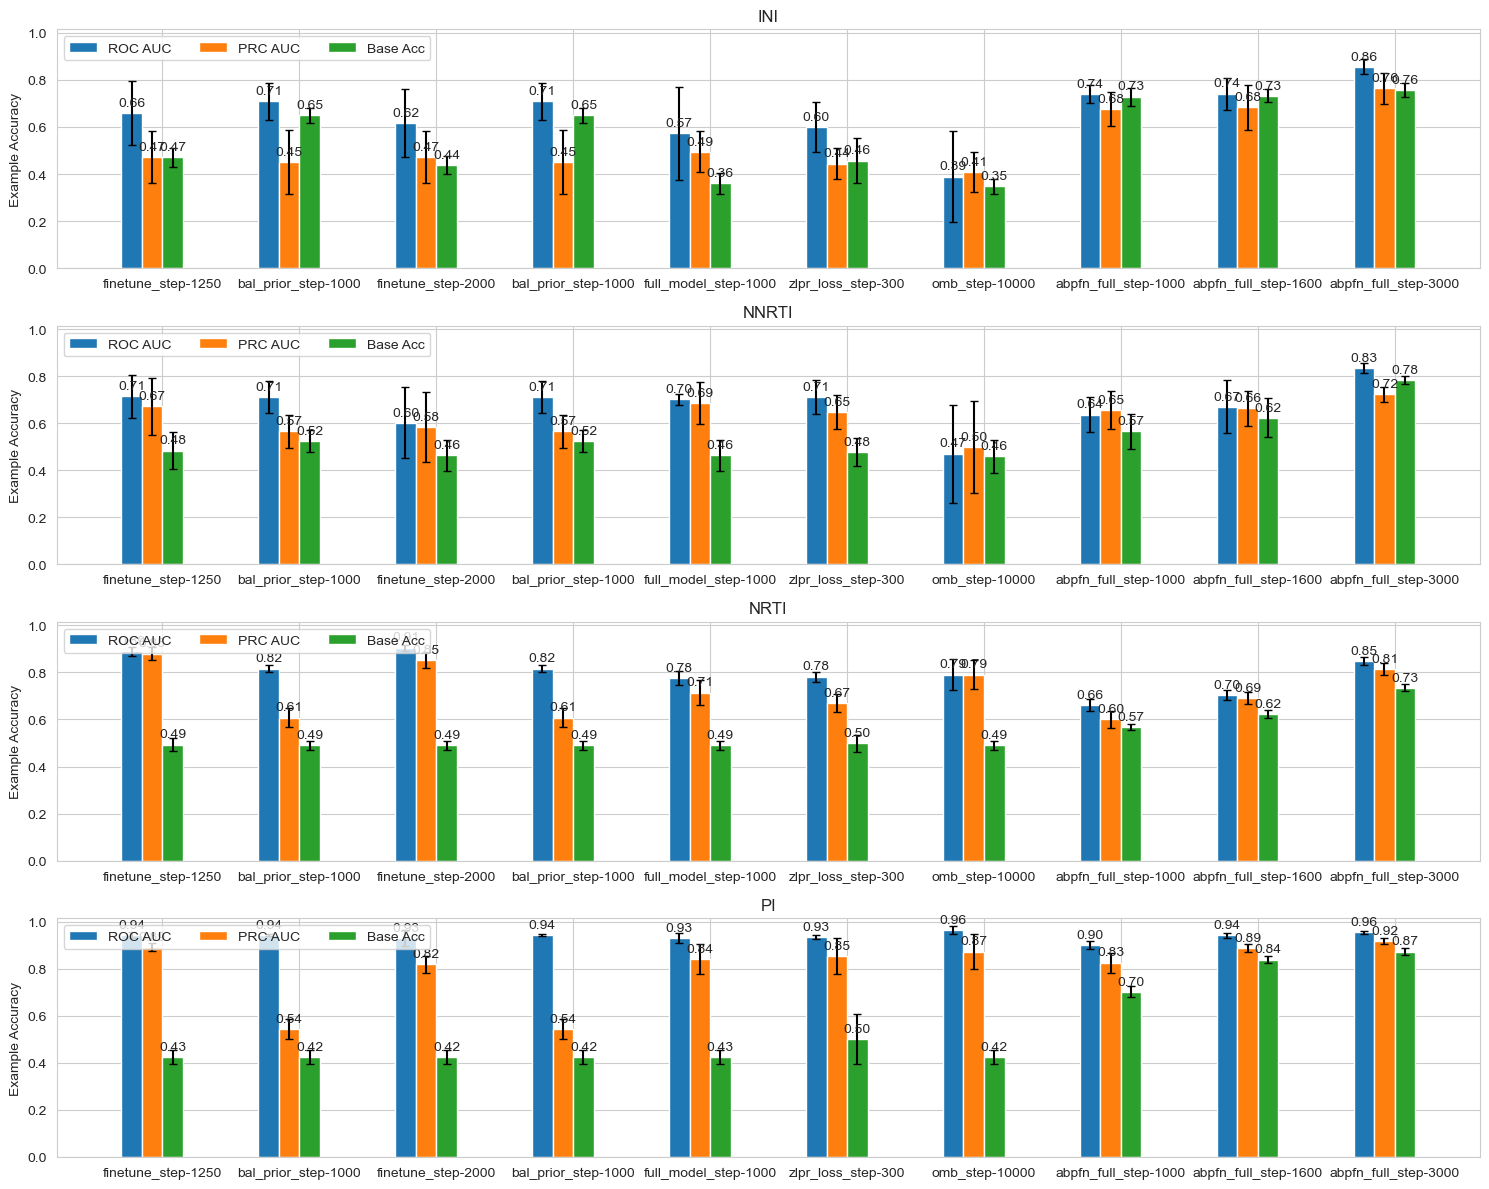

In [23]:


import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import prediction_handler as result_handler
import os
from sklearn.metrics import jaccard_score, roc_auc_score
import result_handler


modeltype = "MuLaTabICL_"

models = [
    "finetune_step-1250",
    "bal_prior_step-1000",
    "finetune_step-2000",
    "bal_prior_step-1000",
    "full_model_step-1000",
    "zlpr_loss_step-300",
    "omb_step-10000",
    "abpfn_full_step-1000",
    "abpfn_full_step-1600",
    "abpfn_full_step-3000"]

ending = "_5_fold_new_loss_sigmoid.csv"



results_mean = []

results_std = []


#path="../prediction_results/scene.csv_results/scene.csv_"



for path in filepath_list:

    print("============" + path.split("/")[-1].strip("_") + "============")

    roc_auc_mean = []
    prc_auc_mean = []
    old_acc_mean = []

    roc_auc_std = []
    prc_auc_std = []
    old_acc_std = []

    for model in models:

        print(model)

        pred = pd.read_csv(path + modeltype + model + ending)
        pred_proba = pd.read_csv(path + modeltype + model + "_probabilities" + ending)

        pred_proba.dropna(subset=pred_proba.columns[pred_proba.columns.str.startswith('True_')].tolist(), inplace=True)
        pred.dropna(subset=pred_proba.columns[pred_proba.columns.str.startswith('True_')].tolist(), inplace=True)


        roc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: roc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*"))), include_groups=False)
        prc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: result_handler.prc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*")), multiclass="ovr"), include_groups=False)
        old_acc = pred.groupby(by="kFolds").apply(lambda x: result_handler.exam_acc(x.filter(regex="True_*"), x.filter(regex="Pred_*")), include_groups=False)

        roc_auc_mean.append(roc_auc.mean())
        roc_auc_std.append(roc_auc.std())

        prc_auc_mean.append(prc_auc.mean())
        prc_auc_std.append(prc_auc.std())

        old_acc_groups = pred.groupby(by="kFolds").apply(
        lambda x: result_handler.exam_acc(x.filter(regex="True_*"), x.filter(regex="Pred_*")),
        include_groups=False)

        old_acc_mean.append(old_acc_groups.mean())
        old_acc_std.append(old_acc_groups.std())


    model_results_mean = {"ROC AUC":roc_auc_mean,
                             "PRC AUC":prc_auc_mean,
                             "Base Acc": old_acc_mean,}

    model_results_std = {"ROC AUC":roc_auc_std,
                         "PRC AUC":prc_auc_std,
                         "Base Acc": old_acc_std,}

    results_mean.append(model_results_mean)
    results_std.append(model_results_std)




x_ticks = models

x = np.arange(len(models))  # the label locations
width = 0.15  # the width of the bars

fig, axs = plt.subplots(4, figsize=(15, 12),layout='tight')

for i, path in enumerate(filepath_list):

    multiplier = -0.5

    ax = axs[i]

    for attribute, measurement in results_mean[i].items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, fmt='%.2f', padding=3)
        ax.errorbar(x + offset, measurement, yerr=results_std[i][attribute],capsize=3, fmt="none", ecolor="black")
        multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Example Accuracy')
    ax.set_title(path.split("/")[-1].strip("_"))
    ax.set_xticks(x + width, models)
    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, 1.015)

plt.show()